# Pre-Processing
1) cut out the first and last 1.5s from the recordings (they’re influenced by the touching of the screen to hit the record/end recording button);

2) cut out stationary moments from the recordings;

3) axis allignment based on the gravity vector, in order to simulate consistent phone orientation for each measurment;

4) Division of each recording into windows and labelling of them (discard windows containing a cut-out due to stationary recording);

5) Pass band filter to keep only the interesting frequencies and remove noise;


In [ ]:

# Initialization of the directories and files used in the preprocessing step.

import os
import pandas as pd

RAW_REC_DIR = "../raw_data"
PRE_PROCESSING_DIR = "../preprocessing"
CUT_OUT_DIR = PRE_PROCESSING_DIR + "/cut_out_start_end"
SENSOR_FILES = ["Accelerometer.csv", "Gyroscope.csv", "Gravity.csv"]


In [ ]:
# Cut-Out script
# Read recordings in each folder and cut the first and last 1.5 seconds meausurements

for recording in os.listdir(RAW_REC_DIR):

    #print(f"Processing {recording}...")
    recording_path = os.path.join(RAW_REC_DIR, recording)
    cutout_recording_path = os.path.join(CUT_OUT_DIR, recording)

    if not os.path.exists(cutout_recording_path):
        os.makedirs(cutout_recording_path)

    for measurement_type in os.listdir(recording_path):

        if measurement_type in SENSOR_FILES:

            raw_file_path = os.path.join(recording_path, measurement_type)
            cutout_file_path = os.path.join(cutout_recording_path, measurement_type)

            # Read the CSV file with pandas

            # pd.read_csv() loads the CSV into a Pandas DataFrame:
            # a tabular structure (map or dictionary) where each column contains an array of values
            # associated with a common row index.
            data = pd.read_csv(raw_file_path)

            # Cut the first and last 1.5 seconds of measurements
            sampling_rate = 100  # Assuming a sampling rate of 100 Hz
            cut_samples = int(1.5 * sampling_rate)

            # Ensure we have enough data to cut
            if len(data) > 2 * cut_samples:
                # iloc selects rows by integer position, excluding the first and last cut_samples rows.
                cut_data = data.iloc[cut_samples:-cut_samples]
                #index=False tells pandas not to save the DataFrame’s row index as an extra column in the CSV file.
                cut_data.to_csv(cutout_file_path, index=False)
                print(f"Processed {recording}: Cut first and last 1.5 seconds.")
            else:
                print(f"Skipping {recording}: Not enough data to cut.")



Processed bumpy_con_tante_buche-2026-09-21_13-24-26: Cut first and last 1.5 seconds.
Processed bumpy_con_tante_buche-2026-09-21_13-24-26: Cut first and last 1.5 seconds.
Processed bumpy_con_tante_buche-2026-09-21_13-24-26: Cut first and last 1.5 seconds.
Processed bumpy_con_una_grande_curva_alla_fine-2026-09-21_13-47-25: Cut first and last 1.5 seconds.
Processed bumpy_con_una_grande_curva_alla_fine-2026-09-21_13-47-25: Cut first and last 1.5 seconds.
Processed bumpy_con_una_grande_curva_alla_fine-2026-09-21_13-47-25: Cut first and last 1.5 seconds.
Processed smooth_ma_con_irregolarita_periodiche_foto_-2026-09-21_13-40-51: Cut first and last 1.5 seconds.
Processed smooth_ma_con_irregolarita_periodiche_foto_-2026-09-21_13-40-51: Cut first and last 1.5 seconds.
Processed smooth_ma_con_irregolarita_periodiche_foto_-2026-09-21_13-40-51: Cut first and last 1.5 seconds.
Processed smooth_strada_universiya_ingresso-2026-09-21_13-29-22: Cut first and last 1.5 seconds.
Processed smooth_strada_uni

### Plotting of the cut out measurments
In order to check if the cut out was done properly we plot one of the resulting modified recordings. 

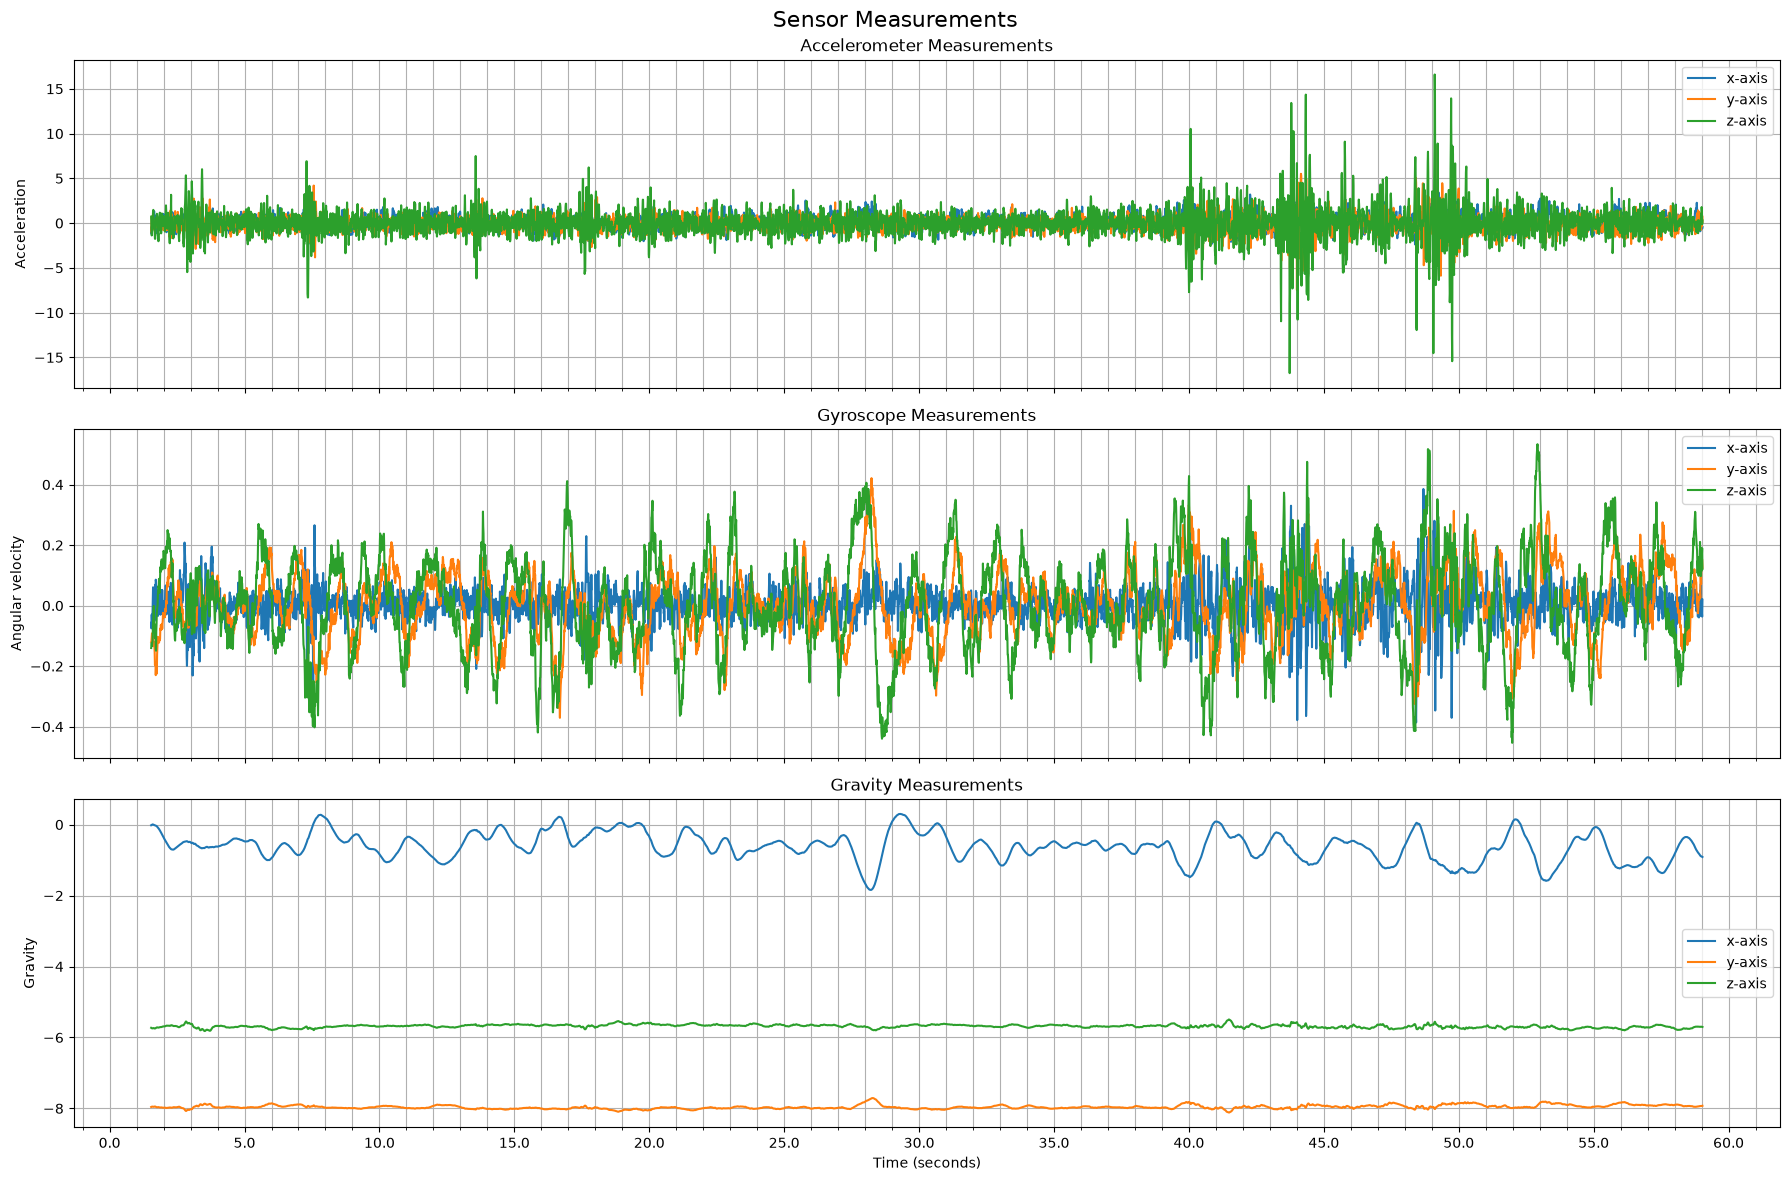

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

PRE_PROCESSING_DIR = "../preprocessing"
CUT_OUT_DIR = f"{PRE_PROCESSING_DIR}/cut_out_start_end"

ACCELEROMETER_DIR = f"{CUT_OUT_DIR}/bumpy_stadio"

AXES = ["x", "y", "z"]

def configure_axis(ax, title, ylabel):
    """Configure a plot axis with common formatting."""
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, which="both")

    ax.xaxis.set_major_locator(MultipleLocator(5.0))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    ax.xaxis.set_minor_locator(MultipleLocator(1.0))

    ax.legend()


def plot_measurement(ax, data, title, ylabel):
    """Plot x, y and z axes of a sensor measurement on the same graph."""
    for axis_name in AXES:
        ax.plot(
            data["seconds_elapsed"],
            data[axis_name],
            label=f"{axis_name}-axis"
        )

    configure_axis(ax, title, ylabel)

# Load data ---------------------------------------------------------

accelerometer = pd.read_csv(
    f"{ACCELEROMETER_DIR}/Accelerometer.csv"
)

gyroscope = pd.read_csv(
    f"{ACCELEROMETER_DIR}/Gyroscope.csv"
)

gravity = pd.read_csv(
    f"{ACCELEROMETER_DIR}/Gravity.csv"
)


# Plot ----------------------------------------------------------------

fig, axes = plt.subplots(
    3,
    1,
    figsize=(18, 12),
    sharex=True
)

plot_measurement(
    axes[0],
    accelerometer,
    "Accelerometer Measurements",
    "Acceleration"
)

plot_measurement(
    axes[1],
    gyroscope,
    "Gyroscope Measurements",
    "Angular velocity"
)

plot_measurement(
    axes[2],
    gravity,
    "Gravity Measurements",
    "Gravity"
)

axes[-1].set_xlabel("Time (seconds)")

fig.suptitle(
    "Sensor Measurements",
    fontsize=16
)

fig.tight_layout()

plt.show()


## Stationary segment removal

We want to remove the stationary segment because they do not influence the final decision of the class of the road.
For instance, if we stop before a traffic light, those 5/10 seconds will be useless for our classification of the quality of the roads.

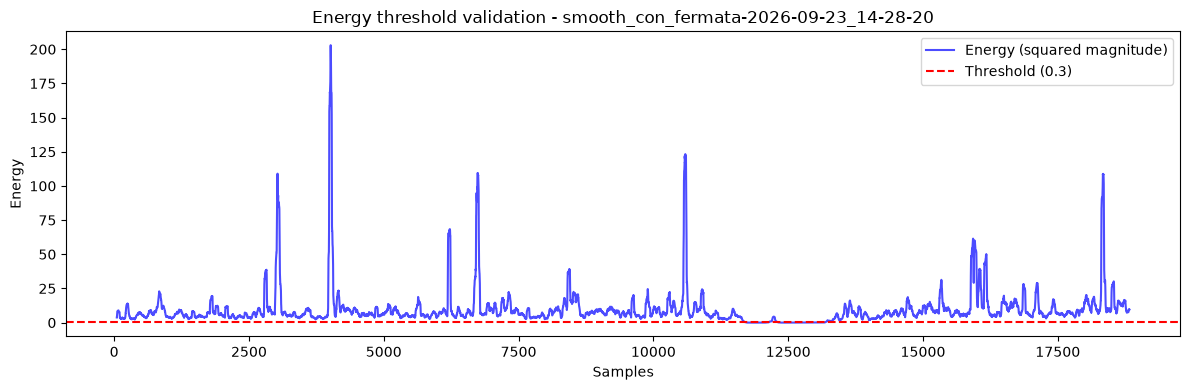

In [20]:
# stationary segment removal script
import pandas as pd
import os
import matplotlib.pyplot as plt

OUTPUT_DIR = "../preprocessing/cut_out_remove_stationary"

VALIDATE_PLOT = True  # Set to True to visualize the energy and threshold for validation

#for each recording, remove the stationary segments based on the accelerometer data
for recording in os.listdir(CUT_OUT_DIR):
    accelerometer_file_path = os.path.join(CUT_OUT_DIR, recording, "Accelerometer.csv")
    accelerometer_data = pd.read_csv(accelerometer_file_path)
    gyroscope_file_path = os.path.join(CUT_OUT_DIR, recording, "Gyroscope.csv")
    gyroscope_data = pd.read_csv(gyroscope_file_path)
    gravity_file_path = os.path.join(CUT_OUT_DIR, recording, "Gravity.csv")
    gravity_data = pd.read_csv(gravity_file_path)

    MAX_ALLOWED_DIFF = 5  # Allow up to 5 samples of difference

    # TODO it should be always the same
    lengths = {
        'Acc': len(accelerometer_data),
        'Gyro': len(gyroscope_data),
        'Grav': len(gravity_data)
    }
    
    max_len = max(lengths.values())
    min_len = min(lengths.values())
    
    # Raise error only if the difference is actually problematic
    if (max_len - min_len) > MAX_ALLOWED_DIFF:
        raise ValueError(f"CRITICAL ERROR in {recording}: Sensors are out of sync! "
                         f"Difference is {max_len - min_len} (max allowed: {MAX_ALLOWED_DIFF}). "
                         f"Lengths: {lengths}")
    
    # Truncate all DataFrames to the shortest length to ensure perfect alignment (by creating copies of the DataFrames)
    acc_work= accelerometer_data.iloc[:min_len]
    gyr_work = gyroscope_data.iloc[:min_len]
    grav_work = gravity_data.iloc[:min_len]

    # Calculate the magnitude of the accelerometer data
    magnitude_vec = (acc_work["x"]**2 + acc_work["y"]**2 + acc_work["z"]**2)**0.5
    energy_threshold = 0.30  # Define a threshold for stationary segments

    # Calculate the energy of the accelerometer data using rolling window mean of the squared magnitude
    energy = (magnitude_vec**2).rolling(window=50).mean()  # Adjust window size as needed

    # Plot the energy and threshold for validation
    if VALIDATE_PLOT:
        plt.figure(figsize=(12, 4))
        plt.plot(energy, label='Energy (squared magnitude)', color='blue', alpha=0.7)
        plt.axhline(y=energy_threshold, color='red', linestyle='--', label=f'Threshold ({energy_threshold})')
        plt.title(f"Energy threshold validation - {recording}")
        plt.xlabel("Samples")
        plt.ylabel("Energy")
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        VALIDATE_PLOT = False

    # Identify stationary segments where energy is below the threshold
    stationary_segments = energy < energy_threshold

    # require that stationary segments are at least 2 seconds long (200 samples at 100 Hz)
    min_stationary_length = 200

    # Runs are windows of datapoints in which either the energy is higher than the treshold or lower of it

    # 1. assign a unique ID to each run of consecutive True values in stationary_segments
    run_ids = (stationary_segments != stationary_segments.shift()).cumsum()
    
    # 2. compute the length of each run of consecutive True values
    run_lengths = stationary_segments.groupby(run_ids).transform('size')
    
    # 3. keep only the runs of consecutive True values that are at least min_stationary_length long
    stationary_segments = stationary_segments & (run_lengths >= min_stationary_length)

    # Remove stationary segments from the all data
    filtered_accelerometer_data = acc_work[~stationary_segments]
    filtered_gyroscope_data = gyr_work[~stationary_segments]
    filtered_gravity_data = grav_work[~stationary_segments]
    
    # create a new folder in preprocessing called cut_out_remove_stationary to store the filtered accelerometer data
    new_folder_path = os.path.join(OUTPUT_DIR, recording)
    os.makedirs(new_folder_path, exist_ok=True)

    # Save the filtered data
    filtered_accelerometer_data.to_csv(os.path.join(new_folder_path, "Accelerometer.csv"), index=False)
    filtered_gyroscope_data.to_csv(os.path.join(new_folder_path, "Gyroscope.csv"), index=False)
    filtered_gravity_data.to_csv(os.path.join(new_folder_path, "Gravity.csv"), index=False)

## Check to see if any part was removed

By plotting the data before and after the stationary parts removal, we can see the differences

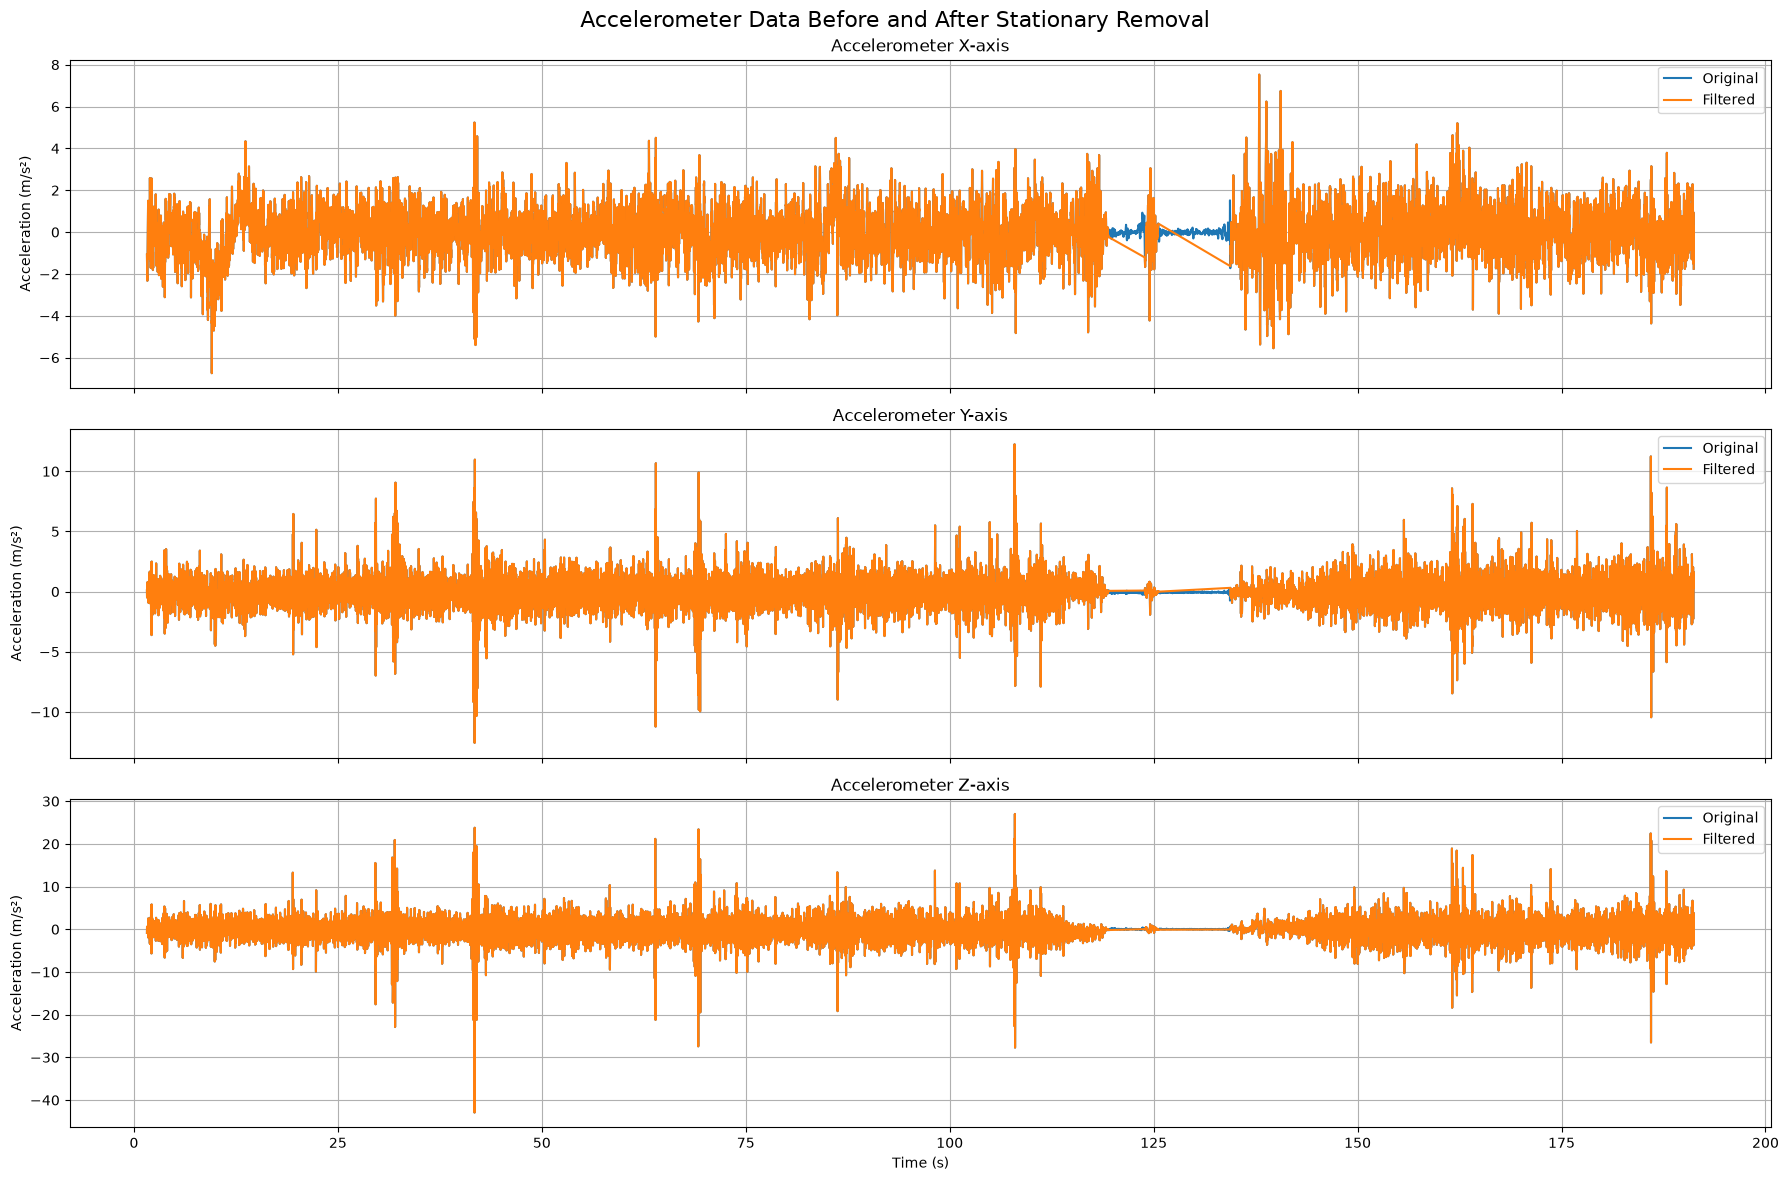

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# load data
recording = "smooth_con_fermata-2026-09-23_14-28-20" # Example with an actual stationary segment

original_accelerometer_data = pd.read_csv(
    os.path.join(CUT_OUT_DIR, recording, "Accelerometer.csv")
)

filtered_accelerometer_data = pd.read_csv(
    os.path.join(OUTPUT_DIR, recording, "Accelerometer.csv")
)

axes_names = ["x", "y", "z"]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(18, 12),
    sharex=True
)

# Plot each axis comparing original with filtered one
for ax, axis_name in zip(axes, axes_names):

    # Original data
    ax.plot(
        original_accelerometer_data["seconds_elapsed"],
        original_accelerometer_data[axis_name],
        label="Original"
    )

    # Filtered data
    ax.plot(
        filtered_accelerometer_data["seconds_elapsed"],
        filtered_accelerometer_data[axis_name],
        label="Filtered"
    )

    ax.set_title(f"Accelerometer {axis_name.upper()}-axis")
    ax.set_ylabel("Acceleration (m/s²)")
    ax.grid(True, which="both")
    ax.legend()


axes[-1].set_xlabel("Time (s)")

fig.suptitle(
    "Accelerometer Data Before and After Stationary Removal",
    fontsize=16
)

fig.tight_layout()
plt.show()


As we can see, the filtering of the recording "smooth_con_fermata-2026-09-23_14-28-20" was performed correctly, removing the data recorded during the stationary periods. 

>In the filtered plots, this is highlighted by the straight lines connecting the end of one movement segment to the beginning of the next, indicating that the data points corresponding to the stationary periods have been removed.

## 3D Orientation Alignment via Rodrigues Rotation

As the data was gathered on different bikes with the same support but not with consistent tilt of it we need to modify the data as if it was gathered with the same consistent setup.

![Axis orientation](../images/axis_orientation.png)



**TODO ADD IMAGE OF TELEPHONE SETUP**




### Data and problem

The three sensors measure in the phone's own axes, so their values depend on how the phone is mounted and on the operating system that records them.


---


### **General Assumptions:**


#### Assumption 0: project setup

- **Phone Setup:** Sensor Logger recordings of bike rides, with the phone fixed on the straight part of the handlebar in a stable condition.
- **Input data:** Accelerometer and Gravity in m/s², Gyroscope in rad/s, columns x, y, z in the phone's axes.
- **Variable mounting:** the **roll angle**, and the **pitch angle** of the holder changes from one recording to another, so the same bike motion ends up on different axes.
- **Different operating systems:** iOS and Android report Accelerometer and Gravity with opposite signs, while the Gyroscope has the same sign.

Goal: express all measurements in one **global reference frame**, identical for every recording and every phone.


#### Assumption 1: yaw angle neglected

Yaw is not estimated: gravity cannot measure it, and GPS, which would be needed to estimate it, is not among the data.

- **Why gravity is not enough:** gravity is a vertical reference. It fixes two of the three angles (pitch and roll); a rotation around the vertical leaves it unchanged.
- **What would be needed:** a horizontal reference, for example the direction of travel or the speed change from GPS, to compare with the accelerations when braking and starting.
- **Assumption adopted:** the phone is fixed on the straight part of the handlebar with the screen facing the rider, so the holder's yaw is zero. The "Z then X" decomposition implements exactly this assumption. A ball-joint holder twisted around the vertical would introduce a real yaw that cannot be detected.
- **Steering:** the handlebar rotates relative to the frame around the steering axis, typically tilted about 18° from the vertical. The rotation is almost entirely yaw and gravity sees only about 30% of it (sin 18°), so it cannot be corrected with gravity. It would require the steering angle at every instant, from a second sensor on the frame or from GPS with a kinematic model.
- **Consequence:** the aligned frame is the handlebar frame and coincides with the bike frame when riding straight. With a steering angle δ, a fraction sin δ of the longitudinal acceleration moves to the lateral axis.
- **Magnitude:** at normal speeds δ is a few degrees; in a curve with a 20 m radius it is about 3° (a 6% fraction). Large values occur only at low speed and when manoeuvring. Steering stays in the data as bike motion, for example on Gyroscope y in curves.

#### Assumption 2: road slope

Road slope is not corrected: without GPS or a barometer it cannot be measured, and the median reduces it to a small constant error on pitch only.

- **Why it is a problem:** gravity measures orientation relative to the vertical, while the reference frame is defined relative to the road. On a slope α, a phone tilted by θ relative to the bike is tilted by θ ± α relative to the vertical: both rotations happen around the same axis, so the angles add. With the typical mount: θ − α uphill, θ + α downhill.
- **What the median does:** it does not remove the slope, it reduces it to a constant error equal to the typical slope of the recording. On flat routes, or routes with both climbs and descents, it cancels out and is close to 0.
- **Worst case:** a constant 5% climb gives a 2.9° error on θ, i.e. about 5% of the vertical component on the longitudinal axis.
- **Only θ, not ψ:** the slope rotates around the same axis as the pitch, so it does not affect the estimate of the phone's rotation inside the holder.
- **Why not sample by sample:** it would not remove the slope; it would introduce it at every instant, together with leaning in curves, braking and fusion errors. With 20° of lean in a curve, 34% of the vertical signal would end up on the lateral axis.
- **Possible check without GPS:** if the same route is recorded in both directions, the difference between the two θ values is about twice the mean slope.


---

### Reference frame

The reference is the phone fixed on the straight part of the handlebar, upright, perpendicular to the road, with the screen facing the rider.
We are going to call the **global reference system** as **bike system**.

| Axis | Physical direction in the reference position |
| --- | --- |
| x | along the handlebar, positive towards the rider's left |
| y | perpendicular to the road, positive downwards |
| z | horizontal, positive towards the travel direction |

The axes are right-handed and coincide with the phone's physical axes, which are the same on iOS and Android. The frame is attached to the handlebar: uphill, y stays perpendicular to the road; in a curve, it leans with the bike.

**Positive direction: iOS convention.** On iOS, Accelerometer and Gravity follow the inertial-force convention, so the Gravity vector points towards the ground. Android uses the opposite sign, the applied-force convention. The Gyroscope uses the same convention on both: positive rotation is counter-clockwise around the axis (right-hand rule).


**Units:** m/s² for Accelerometer and Gravity, rad/s for Gyroscope, on both operating systems.

How to read the aligned data:

| Situation | Expected value |
| --- | --- |
| Bike at rest on flat ground | Gravity ≈ (0, −9.81, 0) m/s² |
| Braking | Accelerometer z < 0 |
| Accelerating forward | Accelerometer z > 0 |
| Left turn | Gyroscope y > 0 |

### Method

For each recording a single rotation R, constant in time, is computed and applied to every sample of the three sensors.

1. **Harmonise the sign convention across operating systems.** The platform is read from the `platform` column of `Metadata.csv`. For Android, and for iOS recorded with the "Standardise Units & Frames" setting on, Accelerometer and Gravity are multiplied by −1; the Gyroscope is unchanged. The state of the setting is read per recording from `Metadata.csv`; the script's `IOS_STANDARDISED` value is used only when it is missing. If the platform is missing, it is inferred from the sign of the y component of gravity: on the holder the phone is never upside down, so in iOS convention it must be negative.


2. **Median gravity vector.** g_med is the component-wise median of Gravity over the whole recording. The holder is fixed, so the pitch to correct is a constant. Instant gravity also changes with steering, leaning in curves, bumps, braking and sensor-fusion errors: the median is not affected, as long as most of the ride is on straight road.


3. **"Z then X" decomposition.** The holder has two degrees of freedom: the phone can be rolled inside the holder by an angle ψ around z, and the holder pitched by an angle θ around the handlebar, i.e. around x. From the upward unit vector u = −g_med / |g_med| the two angles and the rotation are derived (formulas below).

4. **Application.** The same R is applied to Accelerometer, Gyroscope and Gravity, after the sign change of step 1: v' = R · (s · v), with s = ±1 only for Accelerometer and Gravity. With samples stored as rows: X' = (s · X) · Rᵀ. Sign change and rotation commute, so their order does not matter.

Components of u in the phone's axes, as a function of the mounting:


$$
\newline
\theta = pitch angle,  \psi= roll angle
$$


$$
u = \left( \cos\theta \, \sin\psi ,\ \cos\theta \, \cos\psi ,\ -\sin\theta \right)
$$

Inversion:

$$
\psi = \operatorname{atan2}(u_x,\ u_y) \qquad \theta = \operatorname{atan2}\left(-u_z,\ \sqrt{u_x^2 + u_y^2}\right)
$$

Rotation (R_z is applied first, then R_x):

$$
R = R_x(\theta)\, R_z(\psi), \qquad
R_z(\psi) = \begin{pmatrix} \cos\psi & -\sin\psi & 0 \\ \sin\psi & \cos\psi & 0 \\ 0 & 0 & 1 \end{pmatrix}, \qquad
R_x(\theta) = \begin{pmatrix} 1 & 0 & 0 \\ 0 & \cos\theta & -\sin\theta \\ 0 & \sin\theta & \cos\theta \end{pmatrix}
$$

- **R_z(ψ):** straightens the phone in the screen plane and cancels the x component of gravity (roll inside the holder).
- **R_x(θ):** brings the phone upright by rotating it around the handlebar and cancels the z component (pitch).
- **Result:** R · g_med = (0, −|g|, 0).

Signs: θ < 0 means the top of the phone is tilted forward, with the screen facing the sky (typical mount). ψ > 0 means the phone is rotated counter-clockwise, as seen by the rider.

### Why the decomposition and not Rodrigues

Both methods bring gravity onto y, but only the decomposition reconstructs the actual mounting without introducing an artificial yaw.

Infinitely many rotations bring gravity onto y: they differ by a rotation around y, i.e. by the yaw, which gravity cannot see. Rodrigues picks the shortest one, a single rotation around an oblique axis that matches no hinge of the holder. The decomposition follows the two real hinges, so it is consistent with the assumption of zero holder yaw.

Error with respect to the true mounting, in simulation (pitch 40°, phone rotated 10° inside the holder):

| Method | Gravity brought onto y | Error with respect to the true mounting |
| --- | --- | --- |
| Rodrigues | yes | 3.65° (all yaw) |
| Z then X | yes | 0° |
| X then Z | yes | 6.47° |

- **When they coincide:** if ψ = 0 or θ = 0. Rodrigues and the decomposition differ only when both angles are present.
- **Order matters:** "X then Z" corresponds to a different model, a sideways lean like the bike's in a curve.
- **Limit:** with the phone almost horizontal (θ close to ±90°) cos θ tends to 0 and ψ becomes poorly determined. With 1° of noise on gravity, the uncertainty on ψ is 0.8° at θ = 30°, 2.8° at 75° and 8.2° at 85°.

### Automatic checks

For each recording the script prints θ, ψ and the checks below, and finally returns a summary table. The table also records where the sign decision came from: metadata, script setting, or gravity sign.

| Check | Expected value | What a failure indicates |
| --- | --- | --- |
| y component of the median gravity | < 0 | wrong sign convention (platform or standardisation setting) |
| Magnitude of the median gravity | 9.0–10.6 m/s² | unexpected units |
| Absolute value of θ | < 75° | unreliable estimate of ψ |
| Drift between first and last 20% of the recording | < 5° | phone moved inside the holder, or very different road slope at start and end |
| Residual of the aligned gravity | < 1° | alignment failed |
| Yaw difference with respect to Rodrigues | informative only | how much the choice of decomposition matters on real data |

In [4]:
# ==============================================================================
# SENSOR AXIS ALIGNMENT
# ------------------------------------------------------------------------------
# Goal: express Accelerometer, Gyroscope and Gravity of every recording in ONE
# common reference frame, independent of how the phone was mounted on the
# handlebar and of the phone's operating system (iOS / Android).
#
# Reference frame = phone upright on the straight part of the handlebar,
# perpendicular to the road, screen facing the rider:
#   x -> along the handlebar, towards the rider's right
#   y -> perpendicular to the road, upwards
#   z -> horizontal, towards the rider (opposite to the direction of travel)
# Sign convention: iOS. The gravity vector points to the ground, so in the
# reference position Gravity = (0, -g, 0) with g ~ 9.81 m/s^2.
#
# Pipeline, for each recording:
#   1. Bring Accelerometer and Gravity to the iOS sign convention.
#   2. Compute the median gravity vector over the whole recording.
#   3. Build ONE constant rotation R with the "Z then X" decomposition:
#        Rz(psi)   undoes the rotation of the phone inside the holder (roll)
#        Rx(theta) undoes the tilt of the holder around the handlebar (pitch)
#   4. Apply R to every sample of the three sensors and save the result.
#
# Deliberately NOT corrected (see the method description):
#   - Yaw (rotation around the vertical): gravity cannot see it and estimating
#     it would require GPS, which is not available. The holder is assumed to
#     have zero yaw; handlebar steering stays in the data as bike motion.
#   - Road slope: the median reduces it to a small constant error on pitch.
# ==============================================================================
import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------------------
INPUT_DIR_2 = "../preprocessing/cut_out_remove_stationary"
OUTPUT_DIR_3 = "../preprocessing/cut_out_remove_stationary_aligned_v2"

# Sensors to align. All three are 3D vectors in the phone frame, so they are
# rotated with the same matrix R.
SENSORS = ["Accelerometer", "Gyroscope", "Gravity"]

# iOS and Android report Accelerometer and Gravity with opposite signs
# (iOS: inertial-force convention, gravity points down; Android: applied-force
# convention, gravity points up). The Gyroscope uses the same sign on both.
SIGN_FLIPPED_SENSORS = {"Accelerometer", "Gravity"}

# "Standardise Units & Frames" (Sensor Logger setting) converts iOS data to the
# Android convention. It is read per recording from Metadata.csv (any column
# whose name contains "standardis" / "standardiz"). The two values below are
# FALLBACKS, used only when Metadata.csv does not provide the information.
IOS_STANDARDISED = False   # fallback: True if iOS recordings had the setting ON
DEFAULT_PLATFORM = None    # fallback: "ios", "android" or None (= infer from data)

# Direction of gravity in the reference position, iOS convention: straight down.
TARGET_DIR = np.array([0.0, -1.0, 0.0])

# Diagnostic thresholds (degrees)
PITCH_WARN_DEG = 75.0      # phone almost flat -> roll-in-holder estimate unreliable
DRIFT_WARN_DEG = 5.0       # gravity changed between start and end of the recording

os.makedirs(OUTPUT_DIR_3, exist_ok=True)


# ------------------------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------------------------
def unit(v: np.ndarray) -> np.ndarray:
    """Returns v normalised to length 1."""
    n = np.linalg.norm(v)
    if n < 1e-6:
        raise ValueError("Vector magnitude is near zero.")
    return v / n


def angle_between_deg(a: np.ndarray, b: np.ndarray) -> float:
    """Angle (degrees) between two vectors."""
    return float(np.degrees(np.arccos(np.clip(np.dot(unit(a), unit(b)), -1.0, 1.0))))


def rotation_angle_deg(R: np.ndarray) -> float:
    """Angle (degrees) of the rotation represented by matrix R: trace(R) = 1 + 2 cos(angle)."""
    return float(np.degrees(np.arccos(np.clip((np.trace(R) - 1.0) / 2.0, -1.0, 1.0))))


# Accepted spellings for the standardisation flag in Metadata.csv
TRUE_VALUES = {"true", "1", "yes", "y", "on", "enabled", "t"}
FALSE_VALUES = {"false", "0", "no", "n", "off", "disabled", "f"}


def read_metadata(recording_path: str):
    """
    Reads Metadata.csv of one recording and returns (platform, standardised):
      platform     -> "ios", "android" or None            (column "platform")
      standardised -> True / False, or None if missing     (column containing
                      "standardis" or "standardiz"; None also if the value is unreadable)
    """
    for name in ("Metadata.csv", "metadata.csv"):
        path = os.path.join(recording_path, name)
        if not os.path.exists(path):
            continue
        meta = pd.read_csv(path)
        if meta.empty:
            return None, None
        # Column names are matched case-insensitively
        cols = {c.strip().lower(): c for c in meta.columns}

        platform = None
        if "platform" in cols:
            value = str(meta[cols["platform"]].iloc[0]).strip().lower()
            platform = "ios" if "ios" in value else "android" if "android" in value else None

        standardised = None
        std_cols = [c for key, c in cols.items() if "standardis" in key or "standardiz" in key]
        if std_cols:
            value = str(meta[std_cols[0]].iloc[0]).strip().lower()
            if value in TRUE_VALUES:
                standardised = True
            elif value in FALSE_VALUES:
                standardised = False
            else:
                print(f"  Warning: unreadable value '{value}' in column '{std_cols[0]}' of {name}.")
        return platform, standardised
    return None, None


def to_ios_sign(platform, standardised, grav_raw: np.ndarray):
    """
    STEP 1 - sign convention.
    Returns (sign, source):
      sign   -> multiplier for Accelerometer and Gravity:
                +1 = data already in iOS convention, -1 = data in Android convention
      source -> where the decision came from (printed and stored in the summary)
    """
    if platform is None and DEFAULT_PLATFORM is not None:
        platform = DEFAULT_PLATFORM

    # Android is always in Android convention (the setting only affects iOS)
    if platform == "android":
        return -1.0, "platform=android"

    # iOS: raw data are in iOS convention, unless "Standardise Units & Frames" was ON
    if platform == "ios":
        if standardised is not None:
            return (-1.0 if standardised else 1.0), f"metadata standardised={standardised}"
        return (-1.0 if IOS_STANDARDISED else 1.0), f"config IOS_STANDARDISED={IOS_STANDARDISED}"

    # Unknown platform: a handlebar mount never holds the phone upside down, so in
    # iOS convention the y component of gravity must be negative. Use that to decide.
    return (1.0 if np.median(grav_raw[:, 1]) < 0 else -1.0), "inferred from gravity sign"


def rotation_z_then_x(g: np.ndarray):
    """
    STEP 3 - "Z then X" decomposition.

    Mount model: the holder has two "hinges":
      psi   = rotation of the phone inside the holder, around the screen normal (z)
      theta = tilt of the holder around the handlebar (x)
    With u = unit vector pointing UP as seen by the phone, the model gives:
      u = ( cos(theta) sin(psi),  cos(theta) cos(psi),  -sin(theta) )
    so the two angles are recovered as:
      psi   = atan2(u_x, u_y)
      theta = atan2(-u_z, sqrt(u_x^2 + u_y^2))

    The alignment rotation is R = Rx(theta) @ Rz(psi)  (Rz is applied first):
      Rz(psi)   straightens the phone in the screen plane -> gravity x component = 0
      Rx(theta) brings the phone upright around the handlebar -> gravity z component = 0
    Result: R @ g = (0, -|g|, 0).

    Unlike Rodrigues' minimal rotation, this follows the real hinges of the holder,
    so it does not add an artificial yaw when both psi and theta are non-zero.

    Returns (R, theta_deg, psi_deg).
    Sign of the angles: theta < 0 -> top of the phone tilted forward (screen towards
    the sky, typical mount); psi > 0 -> phone rotated counter-clockwise as seen by the rider.
    """
    up = -unit(g)                                        # iOS gravity points down -> flip to get "up"
    psi = np.arctan2(up[0], up[1])                       # roll inside the holder
    theta = np.arctan2(-up[2], np.hypot(up[0], up[1]))   # pitch around the handlebar

    cp, sp = np.cos(psi), np.sin(psi)
    ct, st = np.cos(theta), np.sin(theta)
    Rz = np.array([[cp, -sp, 0.0],
                   [sp,  cp, 0.0],
                   [0.0, 0.0, 1.0]])
    Rx = np.array([[1.0, 0.0, 0.0],
                   [0.0,  ct, -st],
                   [0.0,  st,  ct]])
    return Rx @ Rz, float(np.degrees(theta)), float(np.degrees(psi))


def rotation_rodrigues(u: np.ndarray, t: np.ndarray):
    """
    Minimal rotation that brings u onto t (Rodrigues' formula).
    DIAGNOSTIC ONLY: compared with R to measure how much yaw the choice of the
    decomposition makes on real data. Returns None if u and t are opposite.
    """
    u, t = unit(u), unit(t)
    v, c = np.cross(u, t), float(np.dot(u, t))   # v = axis * sin(angle), c = cos(angle)
    s = np.linalg.norm(v)
    if s < 1e-12:
        return np.eye(3) if c > 0 else None
    vx = np.array([[0, -v[2], v[1]],
                   [v[2], 0, -v[0]],
                   [-v[1], v[0], 0]])
    return np.eye(3) + vx + vx @ vx * ((1 - c) / s**2)


def apply_alignment(df: pd.DataFrame, R: np.ndarray, sign: float = 1.0) -> pd.DataFrame:
    """
    STEP 4 - applies sign and rotation to the x, y, z columns: v' = R @ (sign * v).
    Samples are stored as rows, so in matrix form X' = (sign * X) @ R.T.
    Sign flip and rotation commute, so their order does not matter.
    Other columns (time, seconds_elapsed) and the column order are preserved.
    """
    out = df.copy()
    out[["x", "y", "z"]] = (sign * df[["x", "y", "z"]].to_numpy()) @ R.T
    return out


def start_end_drift_deg(grav_xyz: np.ndarray, frac: float = 0.2) -> float:
    """
    Angle between the median gravity of the first and of the last 20% of the recording.
    A large value means one single R is not valid for the whole recording: the phone
    moved in the holder, or the road slope at start and end was very different.
    """
    k = max(int(len(grav_xyz) * frac), 1)
    return angle_between_deg(np.median(grav_xyz[:k], axis=0), np.median(grav_xyz[-k:], axis=0))


# ------------------------------------------------------------------------------
# MAIN LOOP: one constant rotation per recording
# ------------------------------------------------------------------------------
print(f"Starting alignment (iOS convention, Z-then-X, median gravity) from {INPUT_DIR_2} to {OUTPUT_DIR_3}...\n")
rows = []   # one summary row per recording

for recording in sorted(os.listdir(INPUT_DIR_2)):
    recording_path = os.path.join(INPUT_DIR_2, recording)
    if not os.path.isdir(recording_path):
        continue

    gravity_path = os.path.join(recording_path, "Gravity.csv")
    if not os.path.exists(gravity_path):
        print(f"Warning: No Gravity.csv found for {recording}. Skipping.")
        continue

    # --- STEP 1: sign convention -> iOS --------------------------------------
    grav_raw = pd.read_csv(gravity_path)[["x", "y", "z"]].to_numpy()
    platform, standardised = read_metadata(recording_path)
    sign, sign_source = to_ios_sign(platform, standardised, grav_raw)
    grav = sign * grav_raw

    # --- STEP 2: median gravity vector ---------------------------------------
    # The holder is fixed, so the tilt to correct is a constant. Instant gravity
    # also changes with steering, leaning in curves, bumps, braking and sensor
    # fusion errors; the component-wise median is robust to these short episodes.
    g_med = np.median(grav, axis=0)

    # --- STEP 3: Z-then-X decomposition -> one constant rotation -------------
    R, theta_deg, psi_deg = rotation_z_then_x(g_med)

    # --- Diagnostics ----------------------------------------------------------
    g_norm = float(np.linalg.norm(g_med))       # should be ~9.81 m/s^2
    drift_deg = start_end_drift_deg(grav)        # did the mount stay still?
    R_rod = rotation_rodrigues(g_med, TARGET_DIR)
    # Angle between Rodrigues' rotation and ours = yaw difference between the two methods
    yaw_diff_deg = rotation_angle_deg(R_rod @ R.T) if R_rod is not None else np.nan

    warnings = []
    if g_med[1] >= 0:
        warnings.append("gravity y >= 0 in iOS convention -> wrong sign convention (platform / standardisation)?")
    if not 9.0 < g_norm < 10.6:
        warnings.append(f"median |g| = {g_norm:.2f} -> unexpected units (expected m/s^2)")
    if abs(theta_deg) > PITCH_WARN_DEG:
        warnings.append(f"pitch {theta_deg:.1f} deg -> roll-in-holder estimate unreliable")
    if drift_deg > DRIFT_WARN_DEG:
        warnings.append(f"gravity moved {drift_deg:.1f} deg between start and end -> "
                        "phone moved in the holder, or very different road slope at start/end")

    # --- STEP 4: apply sign + rotation to every sensor and save --------------
    output_recording_path = os.path.join(OUTPUT_DIR_3, recording)
    os.makedirs(output_recording_path, exist_ok=True)
    residual_deg = np.nan
    for sensor in SENSORS:
        sensor_path = os.path.join(recording_path, f"{sensor}.csv")
        if not os.path.exists(sensor_path):
            continue
        s = sign if sensor in SIGN_FLIPPED_SENSORS else 1.0   # gyroscope is never flipped
        aligned_df = apply_alignment(pd.read_csv(sensor_path), R, s)
        aligned_df.to_csv(os.path.join(output_recording_path, f"{sensor}_aligned.csv"), index=False)

        # Check: after alignment the median gravity must point straight down
        if sensor == "Gravity":
            residual_deg = angle_between_deg(np.median(aligned_df[["x", "y", "z"]].to_numpy(), axis=0), TARGET_DIR)

    if residual_deg > 1.0:
        warnings.append(f"aligned gravity is {residual_deg:.1f} deg away from (0, -g, 0)")

    # --- Report ---------------------------------------------------------------
    print(f"{recording} | {platform} (sign {sign:+.0f}, {sign_source}) | pitch {theta_deg:+.1f} deg | "
          f"roll in holder {psi_deg:+.1f} deg | drift {drift_deg:.1f} deg | yaw diff vs Rodrigues {yaw_diff_deg:.2f} deg")
    for w in warnings:
        print(f"  WARNING: {w}")

    rows.append({
        "recording": recording,
        "platform": platform,
        "standardised": standardised,
        "sign_to_ios": sign,
        "sign_source": sign_source,
        "pitch_deg": round(theta_deg, 2),
        "roll_in_holder_deg": round(psi_deg, 2),
        "median_g_norm": round(g_norm, 3),
        "start_end_drift_deg": round(drift_deg, 2),
        "yaw_diff_vs_rodrigues_deg": round(yaw_diff_deg, 2),
        "aligned_gravity_residual_deg": round(residual_deg, 3),
        "warnings": "; ".join(warnings),
    })

print(f"\nAlignment complete! Data saved in {OUTPUT_DIR_3}")

# Summary table (displayed by the notebook as the cell output)
alignment_summary = pd.DataFrame(rows)
alignment_summary


Starting alignment (iOS convention, Z-then-X, median gravity) from ../preprocessing/cut_out_remove_stationary to ../preprocessing/cut_out_remove_stationary_aligned_v2...

bumpy_con_tante_buche-2026-09-21_13-24-26 | None (sign +1, inferred from gravity sign) | pitch +0.3 deg | roll in holder +2.1 deg | drift 1.0 deg | yaw diff vs Rodrigues 0.01 deg
bumpy_con_una_grande_curva_alla_fine-2026-09-21_13-47-25 | None (sign +1, inferred from gravity sign) | pitch -13.1 deg | roll in holder +3.2 deg | drift 0.9 deg | yaw diff vs Rodrigues 0.37 deg
bumpy_stadio | None (sign +1, inferred from gravity sign) | pitch -35.4 deg | roll in holder +4.2 deg | drift 2.0 deg | yaw diff vs Rodrigues 1.33 deg
bumpy_stazione | None (sign +1, inferred from gravity sign) | pitch -35.0 deg | roll in holder +3.3 deg | drift 0.7 deg | yaw diff vs Rodrigues 1.03 deg
bumpy_stradabumpy_con_rialzi_e_buche-2026-09-21_13-44-51 | None (sign +1, inferred from gravity sign) | pitch -14.4 deg | roll in holder +2.7 deg | dri

,recording,platform,standardised,sign_to_ios,sign_source,pitch_deg,roll_in_holder_deg,median_g_norm,start_end_drift_deg,yaw_diff_vs_rodrigues_deg,aligned_gravity_residual_deg,warnings
0,bumpy_con_tante_buche-2026-09-21_13-24-26,None,None,1.0,inferred from gravity sign,0.28,2.13,9.800,1.00,0.01,0.001,
1,bumpy_con_una_grande_curva_alla_fine-2026-09-2...,None,None,1.0,inferred from gravity sign,-13.12,3.24,9.799,0.90,0.37,0.015,
2,bumpy_stadio,None,None,1.0,inferred from gravity sign,-35.41,4.18,9.804,1.98,1.33,0.008,
3,bumpy_stazione,None,None,1.0,inferred from gravity sign,-35.02,3.25,9.805,0.70,1.03,0.003,
4,bumpy_stradabumpy_con_rialzi_e_buche-2026-09-2...,None,None,1.0,inferred from gravity sign,-14.39,2.68,9.798,0.54,0.34,0.004,
5,bumpy_swapfiets,None,None,1.0,inferred from gravity sign,-34.27,3.76,9.804,1.67,1.16,0.040,
6,smooth_con_fermata-2026-09-23_14-28-20,None,None,1.0,inferred from gravity sign,-24.95,2.52,9.800,1.15,0.56,0.005,
7,smooth_con_fermata_2-2026-09-23_14-35-33,None,None,1.0,inferred from gravity sign,-24.99,2.32,9.802,1.80,0.51,0.005,
8,smooth_con_un_po_di_rialzi_e_piccoli_tratti_sa...,None,None,1.0,inferred from gravity sign,0.79,2.86,9.803,1.75,0.02,0.001,
9,smooth_grande_curva_apl_inizio-2026-09-21_13-2...,None,None,1.0,inferred from gravity sign,0.17,2.41,9.803,1.76,0.00,0.001,


In [5]:
import os
import numpy as np
import pandas as pd

# ==============================================================================
# CONFIG
# ==============================================================================
INPUT_DIR_2 = "../preprocessing/cut_out_remove_stationary"
OUTPUT_DIR_3 = "../preprocessing/cut_out_remove_stationary_aligned_v2"

# Target direction for gravity (assuming phone mounted vertically with Y pointing down)
# If your phones were mounted flat, change this to np.array([0.0, 0.0, -1.0])
TARGET = np.array([0.0, -1.0, 0.0])

os.makedirs(OUTPUT_DIR_3, exist_ok=True)

# ==============================================================================
# SUPPORT FUNCTIONS
# ==============================================================================
def median_gravity_direction(grav_xyz: np.ndarray) -> np.ndarray:
    """Calculate the median direction (unit vector) of gravity."""
    g = np.median(grav_xyz, axis=0)
    norm = np.linalg.norm(g)
    if norm < 1e-6:
        raise ValueError("Gravity vector magnitude is near zero.")
    return g / norm

def rotation_align(u: np.ndarray, t: np.ndarray = TARGET) -> np.ndarray:
    """
    Computes the minimal rotation matrix R (Rodrigues' formula) such that R @ u = t.
    Includes a fix for the anti-parallel singularity (180-degree rotation).
    """
    v = np.cross(u, t) # sin(theta)
    c = float(np.dot(u, t)) # cos(theta)
    s = np.linalg.norm(v)
    
    # Handle singularity (vectors are parallel or anti-parallel)
    if s < 1e-12: # if s is close to 0 we would end up with division by zero in the last formula
        if c > 0:
            return np.eye(3)  # vectors are practically parallel, so they're already aligned
        else:
            # Anti-parallel: need a 180-degree rotation around an arbitrary perpendicular axis
            perp = np.array([1.0, 0.0, 0.0])
            if abs(u[0]) > 0.9:
                perp = np.array([0.0, 1.0, 0.0])
            v_perp = np.cross(u, perp)
            v_perp = v_perp / np.linalg.norm(v_perp)
            # Rodrigues formula for 180 degrees: R = 2 * v * v^T - I
            return 2.0 * np.outer(v_perp, v_perp) - np.eye(3)
            
    # Standard Rodrigues' rotation formula
    vx = np.array([
        [0, -v[2], v[1]],
        [v[2], 0, -v[0]],
        [-v[1], v[0], 0]
    ])
    return np.eye(3) + vx + vx @ vx * ((1 - c) / s**2)

def apply_rotation(df: pd.DataFrame, R: np.ndarray) -> pd.DataFrame:
    """Applies the rotation matrix R to the x, y, z columns of a DataFrame."""
    out = df.copy()
    # v' = R @ v. Since v is stored as rows, we do v @ R.T
    out[["x", "y", "z"]] = df[["x", "y", "z"]].to_numpy() @ R.T
    return out



# ---------------------------------------------------------------------------------------------
print(f"Starting Rodrigues alignment from {INPUT_DIR_2} to {OUTPUT_DIR_3}...")

for recording in os.listdir(INPUT_DIR_2):
    recording_path = os.path.join(INPUT_DIR_2, recording)
    
    # Skip if the file is not a directory
    if not os.path.isdir(recording_path):
        continue
    
    output_recording_path = os.path.join(OUTPUT_DIR_3, recording)
    os.makedirs(output_recording_path, exist_ok=True)
    
    # Load gravity data
    gravity_path = os.path.join(recording_path, "Gravity.csv")
    if not os.path.exists(gravity_path):
        print(f"Warning: No Gravity.csv found for {recording}. Skipping.")
        continue
    grav_df = pd.read_csv(gravity_path)

    # Calculate Rotation Matrix from Gravity
    u = median_gravity_direction(grav_df[["x", "y", "z"]].to_numpy())
    R = rotation_align(u, TARGET)
    
    tilt_deg = np.degrees(np.arccos(np.clip(np.dot(u, TARGET), -1, 1)))
    print(f"Recording: {recording} | Tilt from target: {tilt_deg:.1f}°")

    # 2. Apply Rotation to all sensors
    sensors = ["Accelerometer", "Gyroscope", "Gravity"]
    
    for sensor in sensors:
        sensor_path = os.path.join(recording_path, f"{sensor}.csv")
        if os.path.exists(sensor_path):
            sensor_df = pd.read_csv(sensor_path)
            aligned_df = apply_rotation(sensor_df, R)
            
            # Save with the same naming convention as the previous method
            out_path = os.path.join(output_recording_path, f"{sensor}_aligned.csv")
            aligned_df.to_csv(out_path, index=False)

print(f"\nRodrigues alignment complete! Data saved in {OUTPUT_DIR_3}")

Starting Rodrigues alignment from ../preprocessing/cut_out_remove_stationary to ../preprocessing/cut_out_remove_stationary_aligned_v2...
Recording: bumpy_con_tante_buche-2026-09-21_13-24-26 | Tilt from target: 2.1°
Recording: bumpy_con_una_grande_curva_alla_fine-2026-09-21_13-47-25 | Tilt from target: 13.5°
Recording: smooth_ma_con_irregolarita_periodiche_foto_-2026-09-21_13-40-51 | Tilt from target: 14.2°
Recording: smooth_strada_universiya_ingresso-2026-09-21_13-29-22 | Tilt from target: 3.0°
Recording: smooth_con_fermata-2026-09-23_14-28-20 | Tilt from target: 25.1°
Recording: smooth_grande_curva_apl_inizio-2026-09-21_13-20-05 | Tilt from target: 2.4°
Recording: bumpy_stadio | Tilt from target: 35.6°
Recording: bumpy_stazione | Tilt from target: 35.2°
Recording: smooth_con_un_po_di_rialzi_e_piccoli_tratti_saltellanti-2026-09-21_13-33-45 | Tilt from target: 3.0°
Recording: smooth_strda_turca-2026-09-21_13-36-20 | Tilt from target: 40.1°
Recording: bumpy_stradabumpy_con_rialzi_e_buche

### Now we can plot the newly aligned data to see the differences between againts the not aligned one.

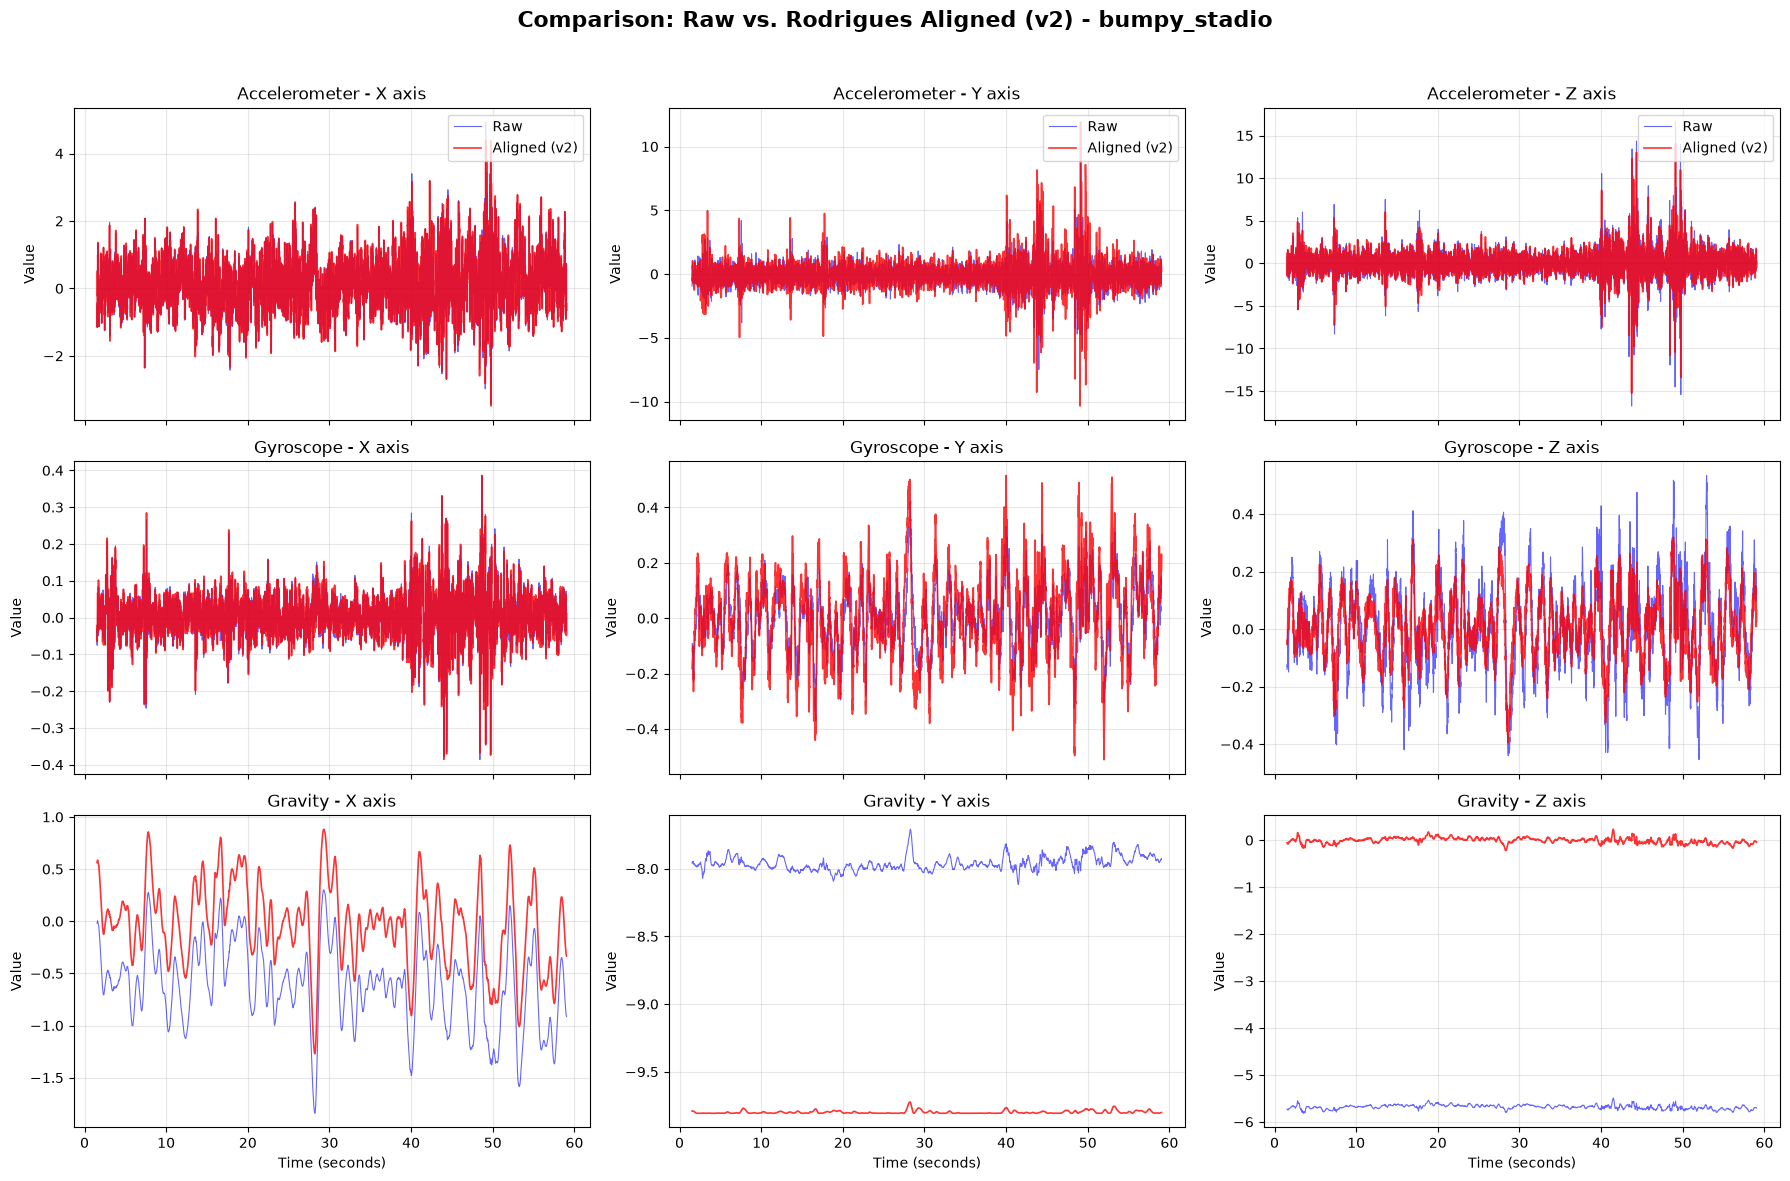

In [36]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Paths
INPUT_DIR_2 = "../preprocessing/cut_out_remove_stationary"
OUTPUT_DIR_3 = "../preprocessing/cut_out_remove_stationary_aligned_v2"

# Pick a recording to visualize (adjust if needed)
RECORDING = "bumpy_stadio" 

# Load data
sensors = ["Accelerometer", "Gyroscope", "Gravity"]
axes = ["x", "y", "z"]

fig, axs = plt.subplots(3, 3, figsize=(18, 12), sharex='col')
fig.suptitle(f'Comparison: Raw vs. Rodrigues Aligned (v2) - {RECORDING}', fontsize=16, fontweight='bold')

for i, sensor in enumerate(sensors):
    # Load raw and aligned data for the current sensor
    raw_path = os.path.join(INPUT_DIR_2, RECORDING, f"{sensor}.csv")
    aligned_path = os.path.join(OUTPUT_DIR_3, RECORDING, f"{sensor}_aligned.csv")
    
    if not os.path.exists(raw_path) or not os.path.exists(aligned_path):
        print(f"Skipping {sensor}: files not found.")
        continue
        
    raw_df = pd.read_csv(raw_path)
    aligned_df = pd.read_csv(aligned_path)
    
    # Use seconds_elapsed for X-axis (assuming it exists and is consistent)
    time = raw_df['seconds_elapsed'].values
    
    for j, axis in enumerate(axes):
        ax = axs[i, j]
        
        # Plot raw data
        ax.plot(time, raw_df[axis].values, label='Raw', color='blue', alpha=0.6, linewidth=0.8)
        
        # Plot aligned data
        ax.plot(time, aligned_df[axis].values, label='Aligned (v2)', color='red', alpha=0.8, linewidth=1.2)
        
        # Formatting
        ax.set_title(f'{sensor} - {axis.upper()} axis')
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)
        
        # Add legend only to the first row to avoid clutter
        if i == 0:
            ax.legend(loc='upper right')
            
        # Add X-axis label only to the bottom row
        if i == 2:
            ax.set_xlabel('Time (seconds)')

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust for suptitle
plt.show()

## Exploratory FFT analysis

Before applying any filtering, it is essential to understand the **frequency characteristics** of our signals. By computing the FFT  for both smooth and bumpy road recordings, we ca for example:

1. **Identify Discriminative Frequency Bands**: We can visually and quantitatively compare which frequencies are present in bumpy roads but absent (or minimal) in smooth roads. This reveals the "spectral signature" of road roughness.

2. **Understand Noise Characteristics**: The FFT reveals high-frequency noise that should be removed, as well as low-frequency components (<1-2 Hz) related to pedaling or gravity residuals that are not relevant for bump detection.

3. **Avoid Signal Loss**: By examining the full spectrum first, we ensure we don't accidentally filter out the very frequencies that distinguish road conditions. This prevents us from discarding valuable information before feature extraction.

This will help us in designing a band pass filter later in the project

**PROBLEM** : Removing stationary segments creates time gaps. If you simply stitch the remaining data together, it creates artificial discontinuities (jumps). These jumps cause spectral leakage, introducing fake high-frequency noise that can ruin the design of your bandpass filter.

**Solution**: To get an accurate exploratory FFT, you must handle these gaps. You can either:
1. Calculate the FFT on each continuous segment separately and then average the results.
2. Simply use only the recordings that had no stationary segments removed for this specific exploratory step.

Since we don't have registrations with stationary parts for now i am going to simply do the second option, but for the band pass filter it's something that we will have to consider, since we don't want to consider this high-frequency noise.






# Exploratory Analysis on Rodrigues-Aligned Data

We are repeating the whole-signal FFT and Spectrogram analysis on the new v2 aligned dataset. Since the Rodrigues rotation preserves all 3 spatial dimensions (X, Y, Z) instead of collapsing them into vertical/horizontal magnitudes, we can now evaluate the frequency content of each physical axis independently. 

We plot both the **non-normalized FFT** (to observe absolute energy differences, e.g., bumpy roads vibrating more overall) and the **normalized FFT** (to isolate the discriminative spectral shape), alongside the time-frequency spectrograms for each axis.

Found 6 bumpy and 9 smooth recordings.


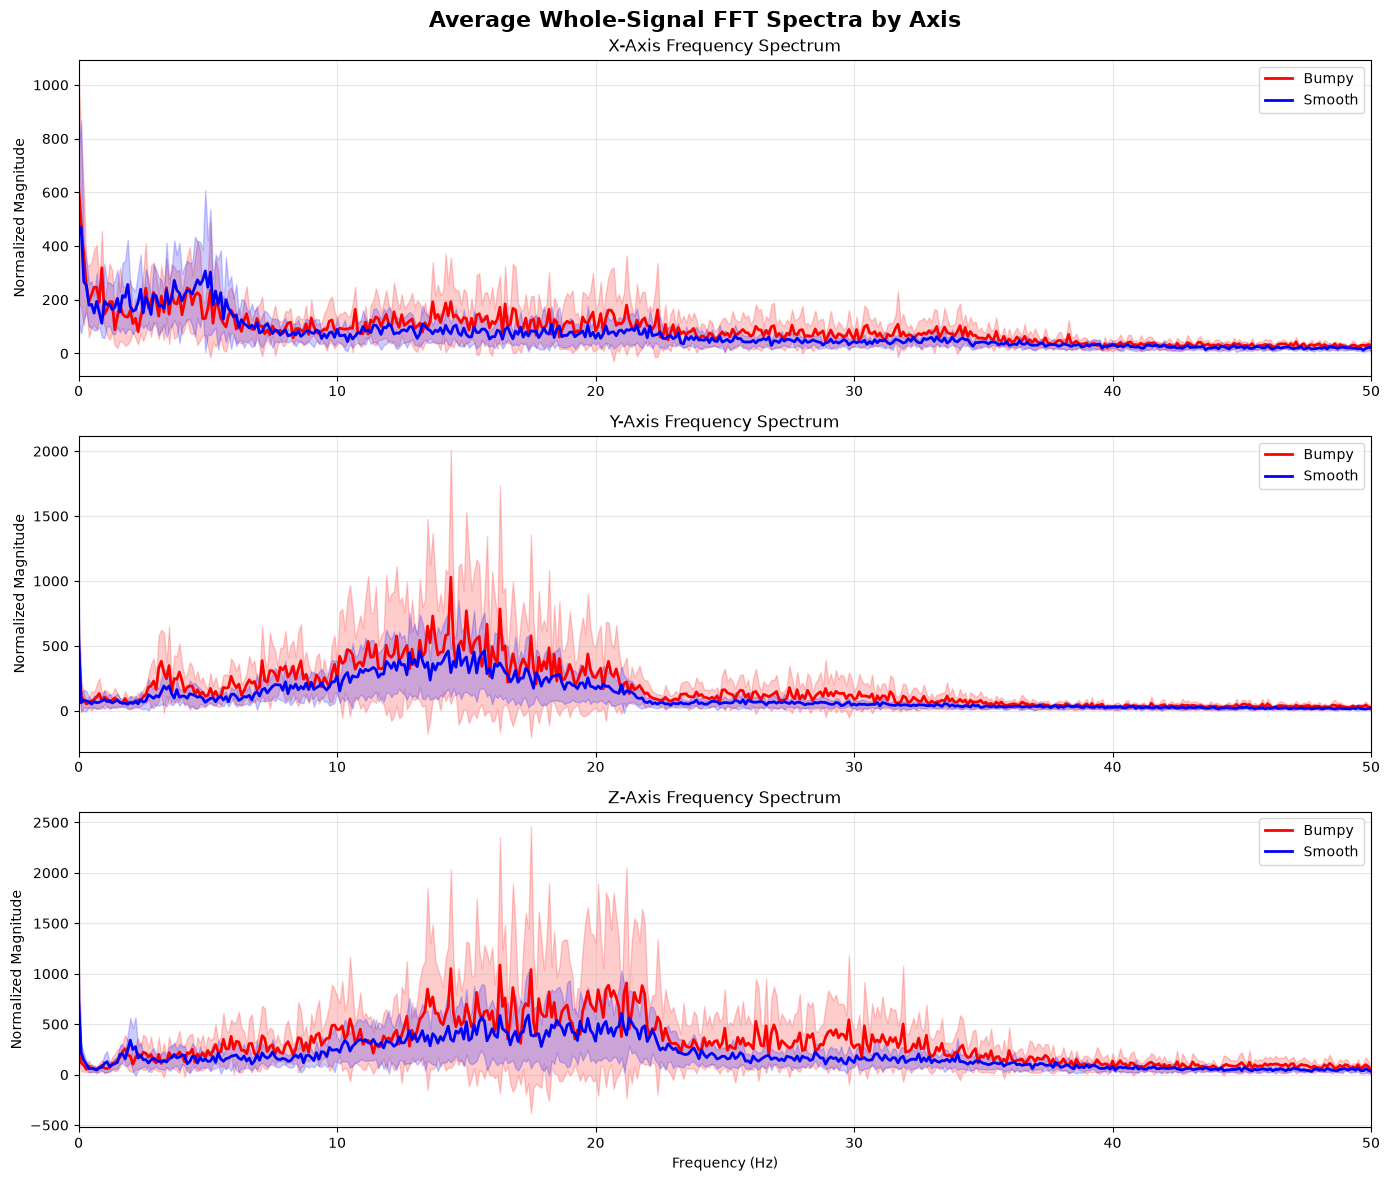

In [51]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import interpolate

# Path to the new v2 aligned directory
OUTPUT_DIR_3 = "../preprocessing/cut_out_remove_stationary_aligned_v2"
fs = 100  # Sampling frequency in Hz

# Keywords to separate recordings
BUMPY_KEYWORD = "bumpy"
SMOOTH_KEYWORD = "smooth"

all_recordings = os.listdir(OUTPUT_DIR_3)
bumpy_recordings = [rec for rec in all_recordings if BUMPY_KEYWORD in rec.lower()]
smooth_recordings = [rec for rec in all_recordings if SMOOTH_KEYWORD in rec.lower()]

print(f"Found {len(bumpy_recordings)} bumpy and {len(smooth_recordings)} smooth recordings.")

def compute_interpolated_fft(filepath, axis, target_freqs):
    data = pd.read_csv(filepath)
    signal = data[axis].values
    n = len(signal)
    
    fft_values = np.fft.rfft(signal)
    fft_freqs = np.fft.rfftfreq(n, 1/fs)
    magnitude = np.abs(fft_values)
    
    # Normalize to compare shape
    magnitudes_normalized = magnitude / (np.sum(magnitude) + 1e-10)
    
    interp_func = interpolate.interp1d(fft_freqs, magnitude, fill_value="extrapolate", bounds_error=False)
    return interp_func(target_freqs)

target_freqs = np.linspace(0, fs/2, 501)
axes_to_plot = ['x', 'y', 'z']

# Create a 3x1 subplot figure
fig, axs = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Average Whole-Signal FFT Spectra by Axis', fontsize=16, fontweight='bold')

for idx, axis in enumerate(axes_to_plot):
    bumpy_spectra = []
    smooth_spectra = []
    
    for rec in bumpy_recordings:
        filepath = os.path.join(OUTPUT_DIR_3, rec, "Accelerometer_aligned.csv")
        if os.path.exists(filepath):
            bumpy_spectra.append(compute_interpolated_fft(filepath, axis, target_freqs))
            
    for rec in smooth_recordings:
        filepath = os.path.join(OUTPUT_DIR_3, rec, "Accelerometer_aligned.csv")
        if os.path.exists(filepath):
            smooth_spectra.append(compute_interpolated_fft(filepath, axis, target_freqs))
            
    # Average and std
    bumpy_avg = np.mean(bumpy_spectra, axis=0) if bumpy_spectra else np.zeros_like(target_freqs)
    bumpy_std = np.std(bumpy_spectra, axis=0) if bumpy_spectra else np.zeros_like(target_freqs)
    
    smooth_avg = np.mean(smooth_spectra, axis=0) if smooth_spectra else np.zeros_like(target_freqs)
    smooth_std = np.std(smooth_spectra, axis=0) if smooth_spectra else np.zeros_like(target_freqs)
    
    # Plot
    ax = axs[idx]
    ax.plot(target_freqs, bumpy_avg, label='Bumpy', color='red', linewidth=2)
    ax.fill_between(target_freqs, bumpy_avg - bumpy_std, bumpy_avg + bumpy_std, color='red', alpha=0.2)
    
    ax.plot(target_freqs, smooth_avg, label='Smooth', color='blue', linewidth=2)
    ax.fill_between(target_freqs, smooth_avg - smooth_std, smooth_avg + smooth_std, color='blue', alpha=0.2)
    
    ax.set_title(f'{axis.upper()}-Axis Frequency Spectrum')
    ax.set_ylabel('Normalized Magnitude')
    ax.set_xlim(0, 50)  # Focus on the relevant 0-30 Hz range
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axs[-1].set_xlabel('Frequency (Hz)')
plt.tight_layout()
plt.show()

## Accelerometer spectral analysis:

**Goal.** Identify the frequency bands in which accelerometer recordings from bumpy roads differ from those from smooth roads, so that we can design a band-pass filter that emphasizes road-surface information and suppresses irrelevant content.

**What we do**

1. **Estimate the power spectral density (PSD)** of each recording with Welch's method. Averaging windowed segments gives a stable estimate that does not depend on recording length, so recordings of different durations are directly comparable. The mean of each segment is removed to discard gravity and sensor offset.
2. **Summarize each class** (bumpy vs smooth) with the median PSD in dB and its interquartile range across recordings, which is robust to outliers and skewed amplitude distributions.
3. **Identify candidate frequency bands** by comparing the PSD distributions of bumpy and smooth recordings and looking for frequency regions where the two classes show a clear and consistent difference across axes (x, y, and z), while avoiding bands dominated by common vehicle or suspension resonances.

**Caveats**
- Bands must be selected on the training data only (or with per-recording cross-validation) to avoid data leakage.
- Frequencies close to Nyquist (> ~40 Hz at fs = 100 Hz) may be dominated by sensor noise.

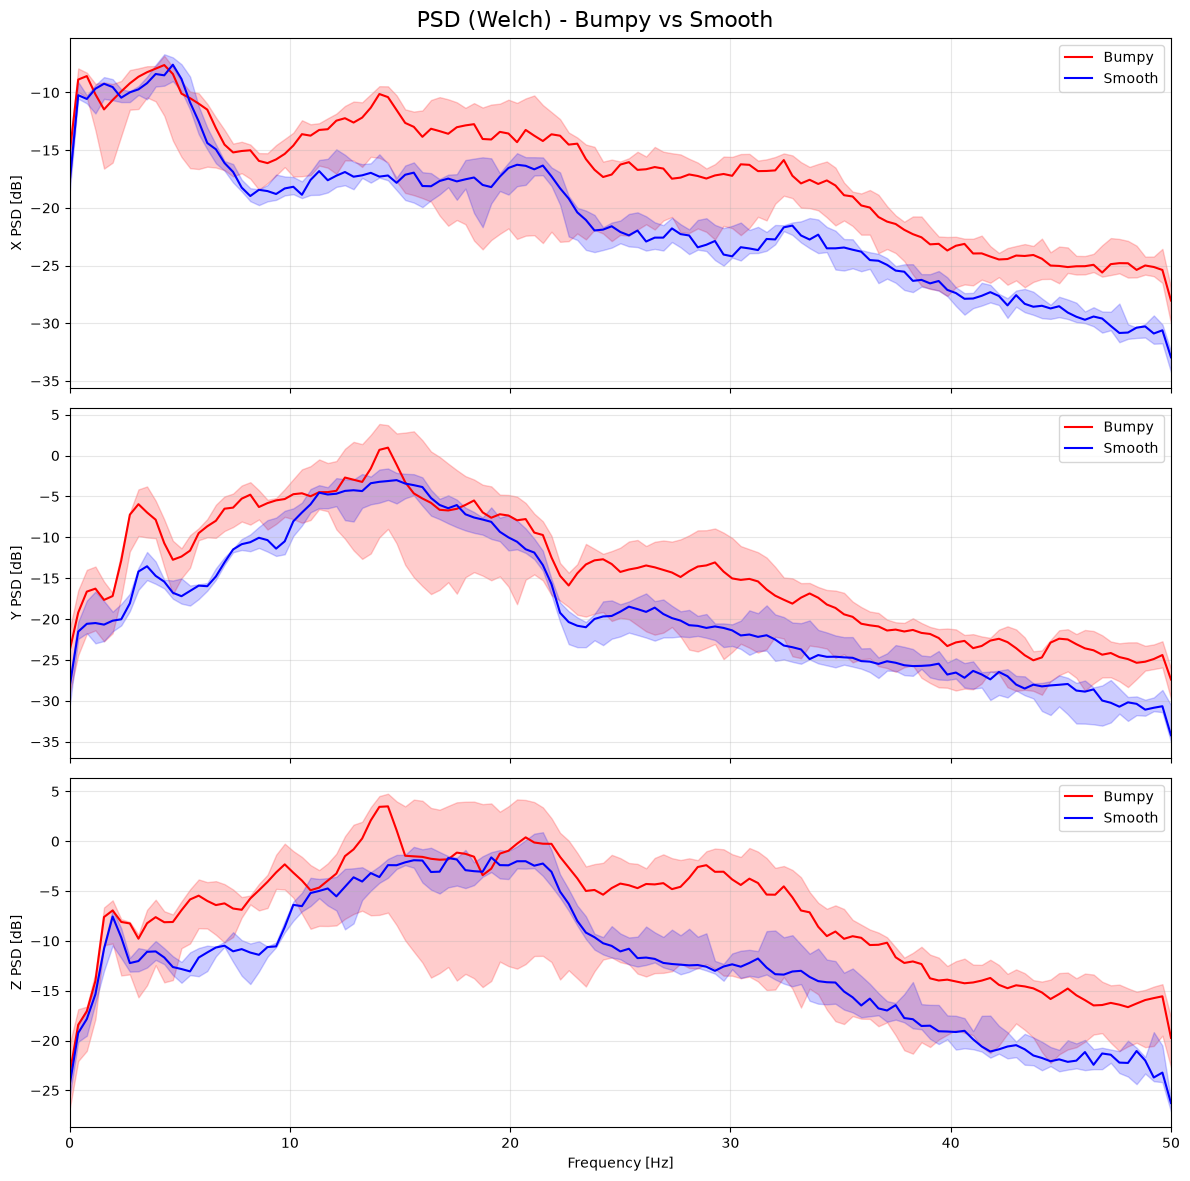

In [59]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as sg
from scipy.stats import mannwhitneyu

OUTPUT_DIR_3 = "../preprocessing/cut_out_remove_stationary_aligned_v2"
fs = 100
NPERSEG = 256

recs = os.listdir(OUTPUT_DIR_3)
bumpy = [r for r in recs if "bumpy" in r.lower()]
smooth = [r for r in recs if "smooth" in r.lower()]

def compute_psd(filepath, axis):
    x = pd.read_csv(filepath)[axis].values.astype(float)
    x = sg.detrend(x, type="constant")          # eliminates DC / gravity
    nperseg = min(NPERSEG, len(x))
    f, pxx = sg.welch(x, fs=fs, window="hann", nperseg=nperseg,
                      noverlap=nperseg // 2)
    return f, pxx

def collect(rec_list, axis):
    spectra, f_ref = [], None
    for r in rec_list:
        p = os.path.join(OUTPUT_DIR_3, r, "Accelerometer_aligned.csv")
        if not os.path.exists(p):
            continue
        f, pxx = compute_psd(p, axis)
        if f_ref is None:
            f_ref = f
        if len(f) == len(f_ref):                # same grid
            spectra.append(pxx)
    return f_ref, np.array(spectra)

fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
fig.suptitle("PSD (Welch) - Bumpy vs Smooth", fontsize=16)

for i, axis in enumerate(["x", "y", "z"]):
    f, B = collect(bumpy, axis)
    _, S = collect(smooth, axis)

    # --- PSD in dB: mediana e percentili 25-75 ---
    for data, color, label in [(B, "red", "Bumpy"), (S, "blue", "Smooth")]:
        db = 10 * np.log10(data + 1e-12)
        med = np.median(db, axis=0)
        q1, q3 = np.percentile(db, [25, 75], axis=0)

        axs[i].plot(f, med, color=color, label=label)
        axs[i].fill_between(f, q1, q3, color=color, alpha=0.2)

    axs[i].set_ylabel(f"{axis.upper()} PSD [dB]")
    axs[i].legend()
    axs[i].grid(alpha=0.3)

axs[-1].set_xlabel("Frequency [Hz]")
axs[0].set_xlim(0, 50)

plt.tight_layout()
plt.show()

## Sequence from this point onwards

1. Spectrogram →

2. Bandpass filter →

3. Windowing (with contextual label) → 

4. Feature extraction (RMS, energy, peaks, etc., per channel)
→ 
5. Correlation between features (Removal of redundant features with the covariance matrix for example)
→ 
6. Mutual information (only on the training fold) → Selection of predictive features
→
7. Normalization (fit only on the training fold)
→
8. Classifier (GroupKFold, baseline, metrics per class)
	​


## Spectrogram

While the global FFT provided the average frequency content to design our bandpass filter, it loses all temporal information. We compute the spectrogram (Short-Time Fourier Transform) to observe how the frequency content evolves over time.


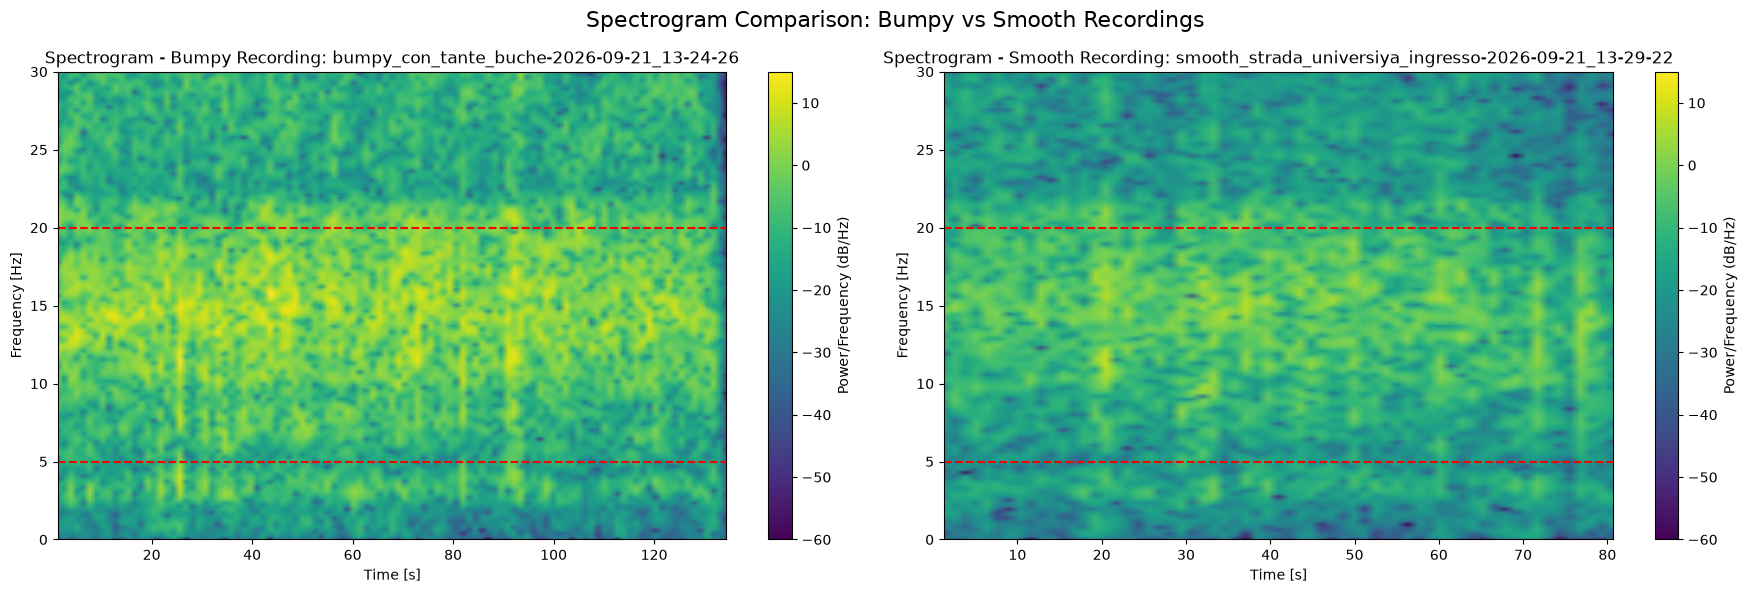

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import os

# path: OUTPUT_DIR_2

# pick one bumpy and one smooth recording for comparison
BUMPY_RECORDING = "bumpy_con_tante_buche-2026-09-21_13-24-26"
SMOOTH_RECORDING = "smooth_strada_universiya_ingresso-2026-09-21_13-29-22"

fs = 100  # Sampling frequency in Hz

#load data
bumpy_data = pd.read_csv(os.path.join(OUTPUT_DIR_2, BUMPY_RECORDING, "Accelerometer_aligned.csv"))
smooth_data = pd.read_csv(os.path.join(OUTPUT_DIR_2, SMOOTH_RECORDING, "Accelerometer_aligned.csv"))

#extract vertical signals
bumpy_vertical = bumpy_data['vertical'].values
smooth_vertical = smooth_data['vertical'].values
time_bumpy = bumpy_data['seconds_elapsed'].values
time_smooth = smooth_data['seconds_elapsed'].values

# Compute the spectrograms
nperseg = 256  # Length of each segment for the spectrogram
noverlap = nperseg // 2  # Overlap between segments
nfft = 512  # Number of FFT points

# compute spectrogram for bumpy recording
f_bumpy, t_bumpy, Sxx_bumpy = signal.spectrogram(bumpy_vertical, fs=fs, nperseg=nperseg, noverlap=noverlap, nfft=nfft, scaling='density', window='hann')

# compute spectrogram for smooth recording
f_smooth, t_smooth, Sxx_smooth = signal.spectrogram(smooth_vertical, fs=fs, nperseg=nperseg, noverlap=noverlap, nfft=nfft, scaling='density', window='hann')

# plot spectograms side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bumpy spectrogram
im1 = axes[0].pcolormesh(t_bumpy, f_bumpy, 10 * np.log10(Sxx_bumpy), shading='gouraud', cmap='viridis',  vmin=-60, vmax=15)
axes[0].set_title(f'Spectrogram - Bumpy Recording: {BUMPY_RECORDING}')
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylim(0, 30)  # Limit frequency axis to 30 Hz
axes[0].axhline(y=5, color='red', linestyle='--')
axes[0].axhline(y=20, color='red', linestyle='--')
plt.colorbar(im1, ax=axes[0], label='Power/Frequency (dB/Hz)')

# Smooth spectrogram
im2 = axes[1].pcolormesh(t_smooth, f_smooth, 10 * np.log10(Sxx_smooth), shading='gouraud', cmap='viridis', vmin=-60, vmax=15)
axes[1].set_title(f'Spectrogram - Smooth Recording: {SMOOTH_RECORDING}')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylim(0, 30)  # Limit frequency axis to 30 Hz
axes[1].axhline(y=5, color='red', linestyle='--')
axes[1].axhline(y=20, color='red', linestyle='--')
plt.colorbar(im2, ax=axes[1], label='Power/Frequency (dB/Hz)')

plt.suptitle('Spectrogram Comparison: Bumpy vs Smooth Recordings', fontsize=16)
plt.tight_layout()
plt.show()

# Insight from this figure

* **Genuine Intensity Difference:** The consistent color scale confirms the higher energy in the 5-20 Hz band for bumpy roads in comparison to smooth roads.
* **Intensity vs. Presence:** Both road types exhibit a baseline vibration in the 5-20 Hz range (likely from pedaling, rolling friction, and frame resonance). Therefore, the **magnitude** of the vibration is the true discriminative feature for our model.
*   **Sustained Roughness vs. Discrete Impacts:** The bumpy spectrogram shows a continuous elevated band rather than isolated vertical streaks. This suggests the recording captures sustained surface roughness rather than isolated potholes. (We have to coonfirm this using a registration with many individual potholes)
*   **Validation of Filter Cutoffs:** Both recordings remain consistently quiet below ~5 Hz and above ~20/22 Hz across the entire time axis. This provides strong confirmation for the design of our band pass filter.


## Rodrigues aligned version.

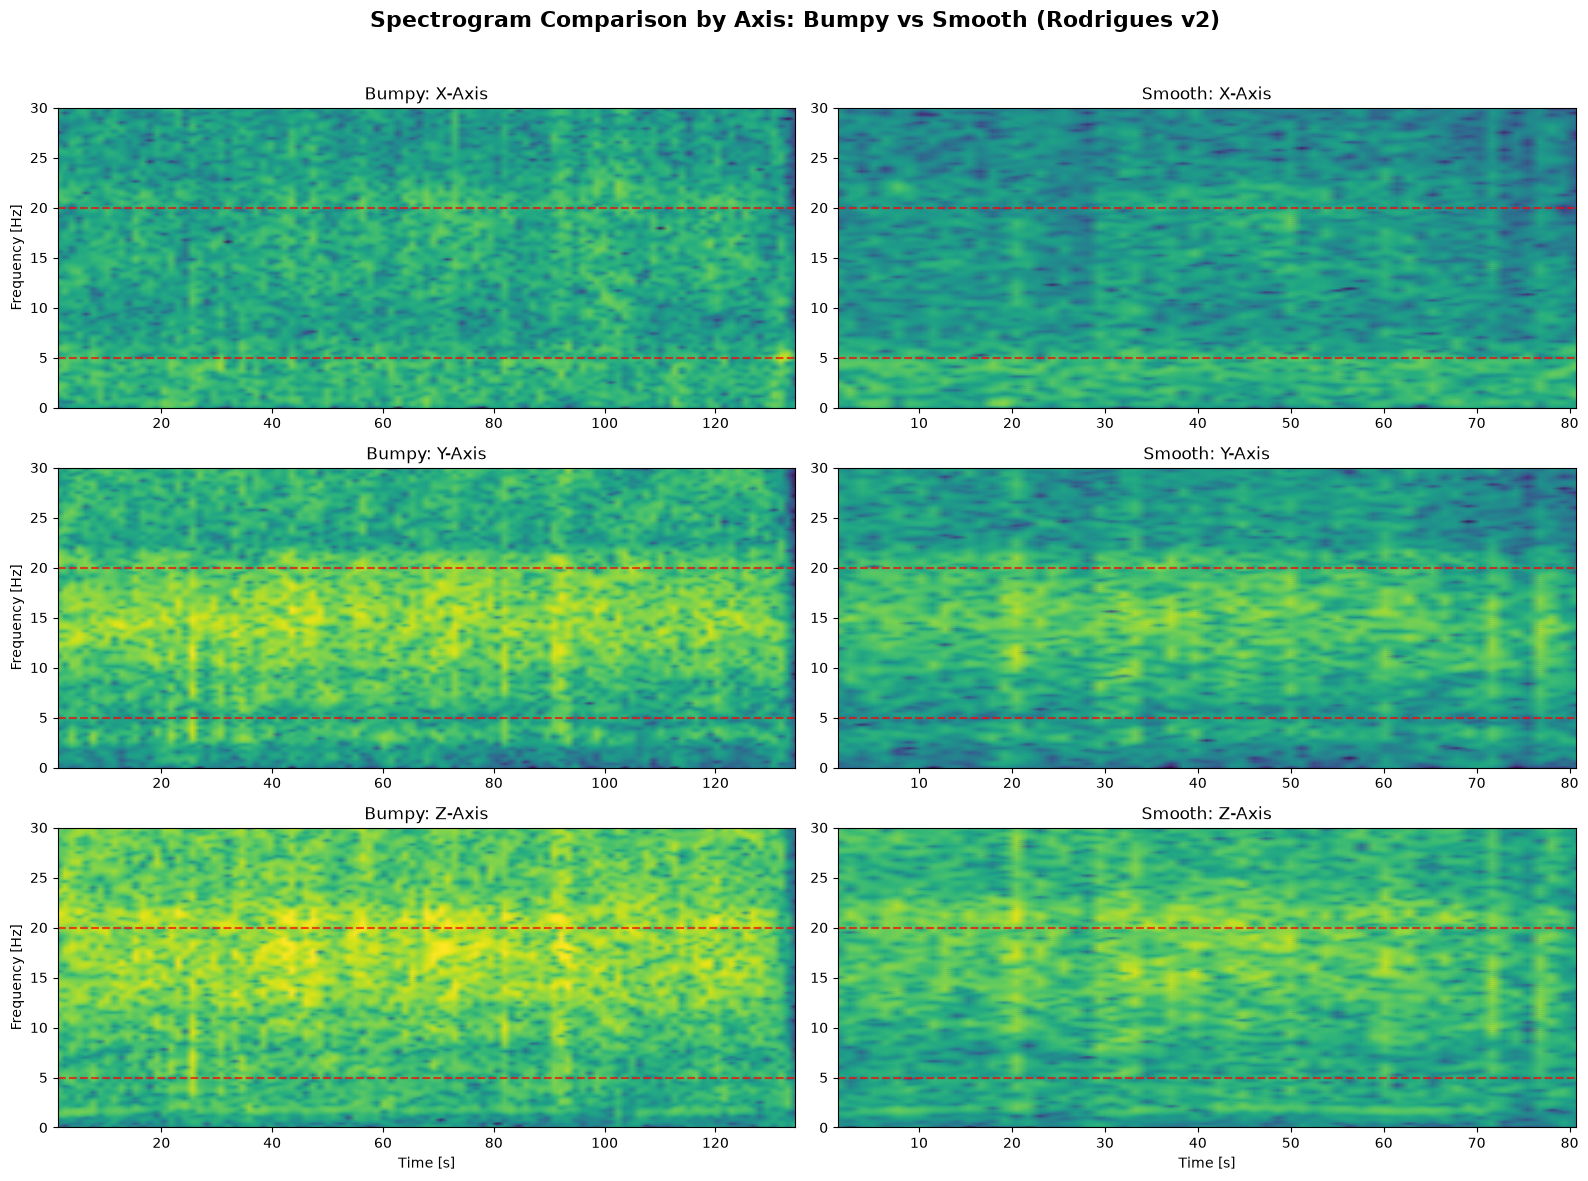

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import os

OUTPUT_DIR_3 = "../preprocessing/cut_out_remove_stationary_aligned_v2"

BUMPY_RECORDING = "bumpy_con_tante_buche-2026-09-21_13-24-26"
SMOOTH_RECORDING = "smooth_strada_universiya_ingresso-2026-09-21_13-29-22"
fs = 100

# Load data
bumpy_data = pd.read_csv(os.path.join(OUTPUT_DIR_3, BUMPY_RECORDING, "Accelerometer_aligned.csv"))
smooth_data = pd.read_csv(os.path.join(OUTPUT_DIR_3, SMOOTH_RECORDING, "Accelerometer_aligned.csv"))

time_bumpy = bumpy_data['seconds_elapsed'].values
time_smooth = smooth_data['seconds_elapsed'].values

# Spectrogram parameters
nperseg = 256
noverlap = nperseg // 2
nfft = 512

axes_to_plot = ['x', 'y', 'z']

# Create a 3x2 grid: 3 rows (X, Y, Z), 2 columns (Bumpy, Smooth)
fig, axs = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Spectrogram Comparison by Axis: Bumpy vs Smooth (Rodrigues v2)', fontsize=16, fontweight='bold')

for row_idx, axis in enumerate(axes_to_plot):
    # Extract signal for the current axis
    sig_bumpy = bumpy_data[axis].values
    sig_smooth = smooth_data[axis].values
    
    # Compute spectrograms
    f_bumpy, t_bumpy, Sxx_bumpy = signal.spectrogram(sig_bumpy, fs=fs, nperseg=nperseg, noverlap=noverlap, nfft=nfft, scaling='density', window='hann')
    f_smooth, t_smooth, Sxx_smooth = signal.spectrogram(sig_smooth, fs=fs, nperseg=nperseg, noverlap=noverlap, nfft=nfft, scaling='density', window='hann')
    
    # --- Column 1: Bumpy ---
    im1 = axs[row_idx, 0].pcolormesh(t_bumpy, f_bumpy, 10 * np.log10(Sxx_bumpy + 1e-10), shading='gouraud', cmap='viridis', vmin=-60, vmax=15)
    axs[row_idx, 0].set_title(f'Bumpy: {axis.upper()}-Axis')
    axs[row_idx, 0].set_ylim(0, 30)
    axs[row_idx, 0].axhline(y=5, color='red', linestyle='--', alpha=0.7)
    axs[row_idx, 0].axhline(y=20, color='red', linestyle='--', alpha=0.7)
    if row_idx == 2:
        axs[row_idx, 0].set_xlabel('Time [s]')
    axs[row_idx, 0].set_ylabel('Frequency [Hz]')
    
    # --- Column 2: Smooth ---
    im2 = axs[row_idx, 1].pcolormesh(t_smooth, f_smooth, 10 * np.log10(Sxx_smooth + 1e-10), shading='gouraud', cmap='viridis', vmin=-60, vmax=15)
    axs[row_idx, 1].set_title(f'Smooth: {axis.upper()}-Axis')
    axs[row_idx, 1].set_ylim(0, 30)
    axs[row_idx, 1].axhline(y=5, color='red', linestyle='--', alpha=0.7)
    axs[row_idx, 1].axhline(y=20, color='red', linestyle='--', alpha=0.7)
    if row_idx == 2:
        axs[row_idx, 1].set_xlabel('Time [s]')

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust for suptitle
plt.show()

## Data Preparation & Feature Engineering (Continued)

From this point onward, we process the aligned data. The pipeline strictly follows this sequence to prevent data leakage and artifacts:
1. **Band-pass Filtering:** Applied *per continuous segment* to avoid `filtfilt` artifacts at the temporal gaps left by stationary removal.
2. **Windowing:** 2.5s windows with 50% overlap to increase sample size and prevent splitting transient events (potholes) across boundaries.
3. **Feature Extraction:** Time and frequency domain metrics computed per window, per channel.


## Band-pass Filtering (Per Continuous Segment)

We apply a 4th-order Butterworth filter (3-22 Hz) to the X, Y, and Z axes of both the Accelerometer and Gyroscope. Crucially, we split the signal at temporal gaps (left by stationary removal) before filtering to avoid artificial transients.

Based on empirical FFT analysis of the Rodrigues-aligned data (X, Y, Z axes), we adjusted the filter cutoffs from the initial 5–20 Hz estimate to **3–22 Hz**:

- **Lower cutoff (3 Hz):** The X-axis (longitudinal) shows energy in the 3–5 Hz range, likely corresponding to forward/backward "jerks" when the bike encounters bumps. Cutting off at 5 Hz would discard this signal.

- **Upper cutoff (22 Hz):** The Z-axis (lateral) maintains relevant energy up to ~22–23 Hz, capturing higher-frequency lateral vibrations from rough surfaces (e.g., cracked asphalt, cobblestones).

- **Y-axis (vertical):** Still shows the primary discriminative band at 5–20 Hz, consistent with our initial FFT analysis.

By widening the passband to 3–22 Hz, we preserve discriminative information across all three spatial axes. The subsequent feature selection step (Mutual Information + correlation filtering) will automatically downweight any non-informative frequencies that do not help separate bumpy from smooth roads.

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt

# Configuration
INPUT_DIR = "../preprocessing/cut_out_remove_stationary_aligned_v2"
FS = 100
LOWCUT = 3.0
HIGHCUT = 22.0
GAP_THRESHOLD = 0.2  # e.g., 5 * (1/100) = 0.05, using 0.1s for safety
MIN_SEGMENT_LENGTH = 50  # Discard segments shorter than 0.5s

def design_butterworth(order, lowcut, highcut, fs, btype='band'):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype=btype)
    return b, a

b, a = design_butterworth(order=4, lowcut=LOWCUT, highcut=HIGHCUT, fs=FS)

filtered_segments = []

for recording in os.listdir(INPUT_DIR):
    rec_path = os.path.join(INPUT_DIR, recording)
    if not os.path.isdir(rec_path):
        continue
        
    acc_path = os.path.join(rec_path, "Accelerometer_aligned.csv")
    gyr_path = os.path.join(rec_path, "Gyroscope_aligned.csv")
    
    if not (os.path.exists(acc_path) and os.path.exists(gyr_path)):
        continue
        
    acc_df = pd.read_csv(acc_path)
    gyr_df = pd.read_csv(gyr_path)

    # Before combining DataFrames:
    assert len(acc_df) == len(gyr_df), f"Length mismatch in {recording}: acc={len(acc_df)}, gyr={len(gyr_df)}"
    
    # Keep them in a combined structure per segment to ensure time-synchronized windowing later
    df = pd.DataFrame({
        'seconds_elapsed': acc_df['seconds_elapsed'],
        'acc_x': acc_df['x'], 'acc_y': acc_df['y'], 'acc_z': acc_df['z'],
        'gyr_x': gyr_df['x'], 'gyr_y': gyr_df['y'], 'gyr_z': gyr_df['z']
    })
    
    # Split at temporal gaps left by stationary removal
    dt = df['seconds_elapsed'].diff()
    gap_indices = np.where(dt > GAP_THRESHOLD)[0]
    
    # np.split creates continuous segments between the gaps
    boundaries = [0] + list(gap_indices) + [len(df)]
    continuous_segments = [df.iloc[boundaries[i]:boundaries[i+1]] for i in range(len(boundaries)-1)]
    
    for segment in continuous_segments:
        if len(segment) < MIN_SEGMENT_LENGTH:
            continue
            
        # Apply bandpass filter to the segment
        filtered_segment = segment.copy()
        channels = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
        for ch in channels:
            filtered_segment[ch] = filtfilt(b, a, segment[ch].values)
            
        # Store filtered segment with its original timestamps and recording name
        filtered_segment['recording_name'] = recording
        filtered_segments.append(filtered_segment)

print(f"Generated {len(filtered_segments)} filtered continuous segments.")

## Windowing Phase (also handles the labeling)

Here we create the windows and assign the label based on the session_id we saved in the previous step.

We extract 3s windows with 30% overlap. 
- **Why overlap?** It increases our training observations (critical given limited sessions) and ensures a transient event (like a single pothole) isn't split exactly on a window boundary, which would dilute its signature in both adjacent windows.
- **Safety check:** We verify that the window duration matches the expected duration to catch any residual gap artifacts.

In [ ]:
WINDOW_SEC = 3
OVERLAP = 0.3
WINDOW_SAMPLES = int(WINDOW_SEC * FS)
STEP_SAMPLES = int(WINDOW_SAMPLES * (1 - OVERLAP))

windows_data = []

# Group segments by recording to derive the label once per recording
from collections import defaultdict
segments_by_recording = defaultdict(list)

# Group segments by recording name
for seg in filtered_segments:
    segments_by_recording[seg['recording_name'].iloc[0]].append(seg)


for recording_name, segments in segments_by_recording.items():
    # Determine label based on recording name
    label = 1 if "bumpy" in recording_name.lower() else 0 if "smooth" in recording_name.lower() else None
    if label is None:
        print(f"Warning: Could not determine label for recording {recording_name}. Skipping.")
        continue
    
    for segment in segments:
        segment_length = len(segment)
        if segment_length < WINDOW_SAMPLES:
            continue  # Skip segments shorter than the window size

        for start in range(0, segment_length - WINDOW_SAMPLES + 1, STEP_SAMPLES):
            window = segment.iloc[start:start + WINDOW_SAMPLES].copy()

            t_start = window['seconds_elapsed'].iloc[0]
            t_end = window['seconds_elapsed'].iloc[-1]

            # Safety check: Ensure the window does not have residual gaps by checking the time difference
            if (t_end - t_start) > ( WINDOW_SEC + 0.1):  
                continue  # Skip windows that span a gap

            # Store the window data along with its label
            windows_data.append({
                'group_id': recording_name,
                'label': label,
                'data': window
            })

### 3. Feature Extraction

For each window and each of the 6 channels, we extract time-domain and frequency-domain features. 
*(Note: Channel names are adapted to `acc_x`, `acc_y`, `acc_z`, etc., to match the Rodrigues v2 aligned data).*

In [ ]:
from scipy.signal import welch, find_peaks

def extract_features(signal_1d, fs=FS):
    """
    Extracts time-domain and frequency-domain features from a 1D signal.
    Returns a dictionary of features.
    """

    n = len(signal_1d)
    
    def make_empty_features():
        return {
            'mean': np.nan,
            'std': np.nan,
            'rms': np.nan,
            'max': np.nan,
            'min': np.nan,
            'peak_to_peak': np.nan,
            'peak_count': np.nan,
            'energy': np.nan,
            'dominant_freq': np.nan,
            'spectral_centroid': np.nan,
            'spectral_entropy': np.nan,
            'band_energy_3_5Hz': np.nan,
            'band_energy_5_10Hz': np.nan,
            'band_energy_10_15Hz': np.nan,
            'band_energy_15_20Hz': np.nan,
            'band_energy_20_22Hz': np.nan,
            'geometric_mean': np.nan,
            'arithmetic_mean': np.nan,
            'spectral_flatness': np.nan
        }

    if n == 0:
        return make_empty_features()

    # Time-domain features
    mean_val = np.mean(signal_1d)
    std_val = np.std(signal_1d)
    rms_val = np.sqrt(np.mean(signal_1d**2))
    max_val = np.max(signal_1d)
    min_val = np.min(signal_1d)
    peak_to_peak = max_val - min_val

    # Peak counts: number of peaks above mean + 0.5std
    peaks, _ = find_peaks(np.abs(signal_1d - mean_val), height=0.5 * std_val)
    peak_count = len(peaks)

    energy = np.sum(signal_1d**2)

    # Frequency-domain features using Welch's method
    nperseg = min(n, n // 2)  # Use half the window size
    if nperseg < 16:
        nperseg = n  # Use the entire signal if too short

    freqs, psd = welch(signal_1d, fs=fs, nperseg=nperseg)
    psd_sum = np.sum(psd)
    if psd_sum == 0:
        psd_sum = 1e-10  # Avoid division by zero
    psd_normalized = psd / psd_sum

    # Band energy
    band_energy = {
        '3-5Hz': np.sum(psd[(freqs >= 3) & (freqs < 5)]),
        '5-10Hz': np.sum(psd[(freqs >= 5) & (freqs < 10)]),
        '10-15Hz': np.sum(psd[(freqs >= 10) & (freqs < 15)]),
        '15-20Hz': np.sum(psd[(freqs >= 15) & (freqs < 20)]),
        '20-22Hz': np.sum(psd[(freqs >= 20) & (freqs < 22)]),
    }

    # Dominant frequency
    dominant_freq = freqs[np.argmax(psd)]

    # Spectral centroid
    spectral_centroid = np.sum(freqs * psd_normalized) / np.sum(psd_normalized)

    # Spectral entropy
    epsilon = 1e-10  # Small value to avoid log(0)
    spectral_entropy = -np.sum(psd_normalized * np.log2(psd_normalized + epsilon))

    # Spectral flatness (geometric mean / arithmetic mean)
    geometric_mean = np.exp(np.mean(np.log(psd_normalized + epsilon)))
    arithmetic_mean = np.mean(psd_normalized)
    spectral_flatness = geometric_mean / arithmetic_mean




    return {
        'mean': mean_val,
        'std': std_val,
        'rms': rms_val,
        'max': max_val,
        'min': min_val,
        'peak_to_peak': peak_to_peak,
        'peak_count': peak_count,
        'energy': energy,
        'dominant_freq': dominant_freq,
        'spectral_centroid': spectral_centroid,
        'spectral_entropy': spectral_entropy,
        'band_energy_3_5Hz': band_energy['3-5Hz'],
        'band_energy_5_10Hz': band_energy['5-10Hz'],
        'band_energy_10_15Hz': band_energy['10-15Hz'],
        'band_energy_15_20Hz': band_energy['15-20Hz'],
        'band_energy_20_22Hz': band_energy['20-22Hz'],
        'geometric_mean': geometric_mean,
        'arithmetic_mean': arithmetic_mean,
        'spectral_flatness': spectral_flatness
    }

channels = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
feature_rows = []

for window in windows_data:

    # Extract the data for the current window
    df_window = window['data']
    feature_row = {
        'group_id': window['group_id'],
        'label': window['label'],
    }

    for ch in channels:
        signal_1d = df_window[ch].values
        features = extract_features(signal_1d)

        for feature_name, value in features.items():
            feature_row[f"{ch}_{feature_name}"] = value

    feature_rows.append(feature_row)

# Create a DataFrame from the feature rows
feature_table = pd.DataFrame(feature_rows)
print(f"Feature table created with shape: {feature_table.shape}")


   

